# A Study on the Relationships Between Sentiment Indexes and Bitcoin Price

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
import seaborn as sns # Import the seaborn library and assign it the alias 'sns'
import pandas as pd
from IPython import get_ipython
from IPython.display import display

# Step 1: Data import

Now i have to import matrix0-1-2 and stuty their time series

## matrix2

In [ ]:
# prompt: UPLOAD THE csv Bitcoin (BTC) 27mar2023-30gen2025 SANTIMENT from my drive at https://drive.google.com/drive/folders/1lQPvAvh4wthmwDpXeVx0qbF2pqaenjeW

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving matrix2.csv to matrix2.csv
User uploaded file "matrix2.csv" with length 62009 bytes


In [ ]:
# prompt: change the name of the columns of matrix2: closing_price to BCP, fear_greed_index to FGI, pageviews to WSI, ITB Sentiment Score to ITB, Bitcoin_Normalized to GTI, santiment to SAN

import pandas as pd

# Assuming 'matrix2.csv' is the uploaded file
matrix2 = pd.read_csv('matrix2.csv')

# Rename the columns
matrix2 = matrix2.rename(columns={
    'closing_price': 'BCP',
    'fear_greed_index': 'FGI',
    'pageviews': 'WVI',
    'ITB Sentiment Score': 'ITB',
    'Bitcoin_Normalized': 'GTI',
    'santiment': 'SAN',
    'galaxy_score': 'LCG'
})

# Now matrix2 has the new column names
print(matrix2.head()) # Display first few rows to verify changes


         date           BCP   FGI   WVI       ITB        GTI  LCG       SAN
0  2023-03-26  27994.330078  64.0  7367 -0.480679  10.847403   42  0.000000
1  2023-03-27  27139.888672  64.0  8056 -0.390391  12.613497   42  7.682213
2  2023-03-28  27268.130859  59.0  8152 -0.505090  12.263122   42  5.432307
3  2023-03-29  28348.441406  57.0  8703 -0.549226  12.613497   42  4.723539
4  2023-03-30  28033.562500  60.0  9144 -0.360882  12.438309   42  4.090893


### Normalizzazione matrix2

In [ ]:
# prompt: normalize all the columns of matrix2 except the date

from sklearn.preprocessing import MinMaxScaler

# Create a MinMaxScaler object
scaler = MinMaxScaler()

# Select columns to normalize (excluding 'Date')
columns_to_normalize = ['BCP', 'FGI', 'WVI', 'ITB', 'GTI', 'SAN', 'LCG']

# Fit and transform the selected columns
matrix2[columns_to_normalize] = scaler.fit_transform(matrix2[columns_to_normalize])

# Display the normalized matrix2
print(matrix2.head())


         date       BCP       FGI       WVI       ITB       GTI       LCG  \
0  2023-03-26  0.035418  0.610390  0.067517  0.316266  0.059030  0.040816   
1  2023-03-27  0.024873  0.610390  0.085534  0.384990  0.086255  0.040816   
2  2023-03-28  0.026455  0.545455  0.088045  0.297684  0.080854  0.040816   
3  2023-03-29  0.039789  0.519481  0.102453  0.264089  0.086255  0.040816   
4  2023-03-30  0.035903  0.558442  0.113985  0.407453  0.083554  0.040816   

        SAN  
0  0.241038  
1  1.000000  
2  0.777721  
3  0.707699  
4  0.645196  


## Matrix2 con Bitcoin Returns

In [ ]:
# prompt: change the closing_price column of matrix2 with its first differences calling the column Bitcoin Returns

matrix2['Bitcoin Returns'] = matrix2['closing_price'].diff()
matrix2.head()

,date,closing_price,fear_greed_index,pageviews,ITB Sentiment Score,Bitcoin_Normalized,galaxy_score,santiment,Bitcoin Returns
0,2023-03-26,27994.330078,64.0,7367,-0.480679,10.847403,42,0.000000,NaN
1,2023-03-27,27139.888672,64.0,8056,-0.390391,12.613497,42,7.682213,-854.441406
2,2023-03-28,27268.130859,59.0,8152,-0.505090,12.263122,42,5.432307,128.242188
3,2023-03-29,28348.441406,57.0,8703,-0.549226,12.613497,42,4.723539,1080.310547
4,2023-03-30,28033.562500,60.0,9144,-0.360882,12.438309,42,4.090893,-314.878906


## MatrixX con altra def ITB.. stessa corr negativa

In [ ]:
import pandas as pd
from google.colab import files

matrix2 = pd.read_csv('matrixX.csv')
matrix2.head()

,date,closing_price,fear_greed_index,pageviews,ITB Sentiment Score,Bitcoin_Normalized,galaxy_score,santiment
0,2023-03-26,27994.330078,64.0,7367,0.163934,10.847403,42,0.000000
1,2023-03-27,27139.888672,64.0,8056,0.221154,12.613497,42,7.682213
2,2023-03-28,27268.130859,59.0,8152,0.126190,12.263122,42,5.432307
3,2023-03-29,28348.441406,57.0,8703,0.308962,12.613497,42,4.723539
4,2023-03-30,28033.562500,60.0,9144,0.299383,12.438309,42,4.090893


## Plot of the time series

In [ ]:
matrix2['date'] = pd.to_datetime(matrix2['date'])

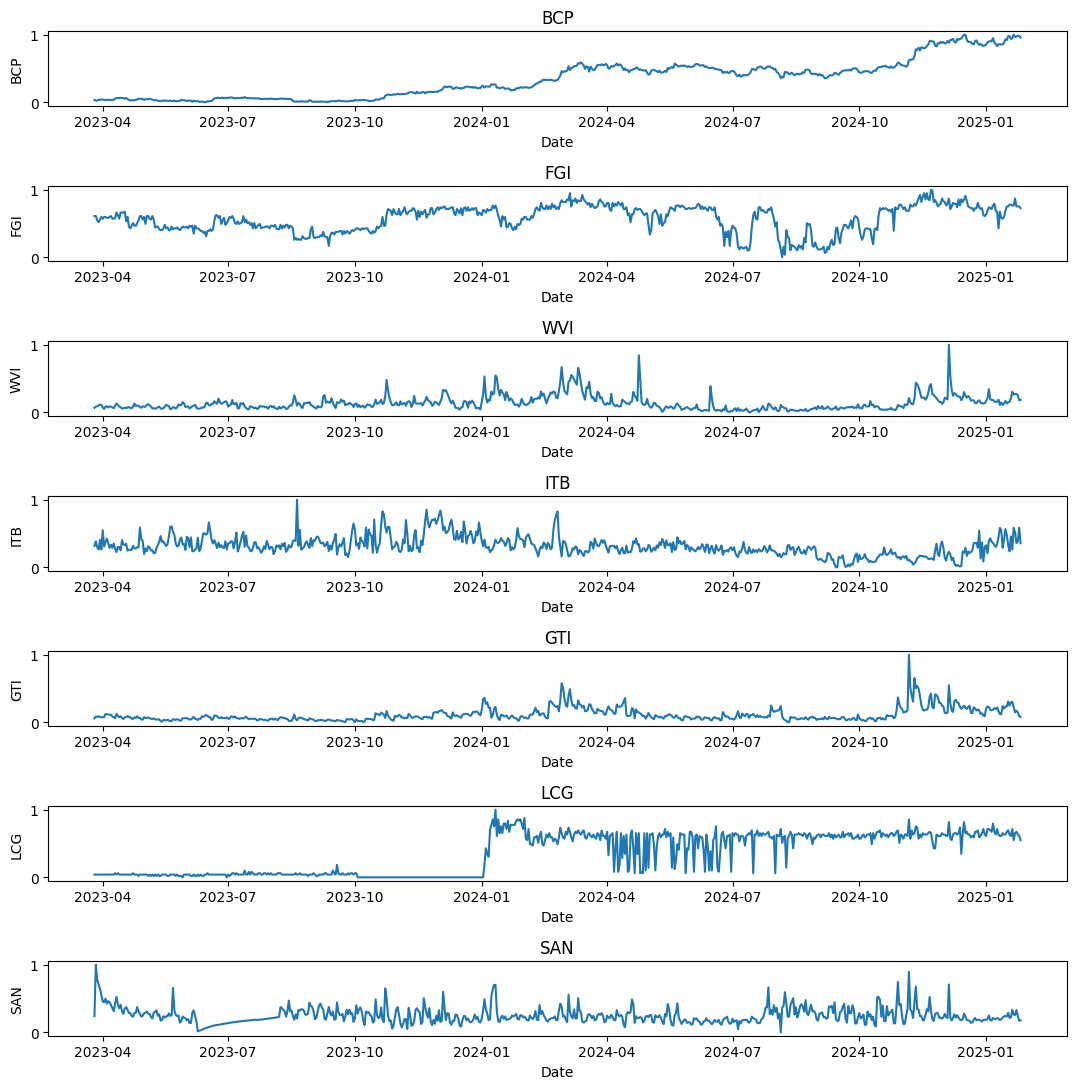

In [ ]:
# Assuming matrix2 is your DataFrame and it has a 'date' column
# Replace 'column_name1', 'column_name2', etc. with the actual column names you want to plot
num_columns = len(matrix2.columns) -1 # Assuming the first column is the date column

fig, axes = plt.subplots(nrows=num_columns, ncols=1, figsize=(11, 11)) # Increased figure width, decreased height

for i, col in enumerate(matrix2.columns[1:]):  # Iterate from the second column onwards
  axes[i].plot(matrix2['date'], matrix2[col]) # Plot against date
  axes[i].set_title(col) # Set title
  axes[i].set_xlabel('Date') # Set x label
  axes[i].set_ylabel(col) # Set y label


plt.tight_layout()
plt.show()

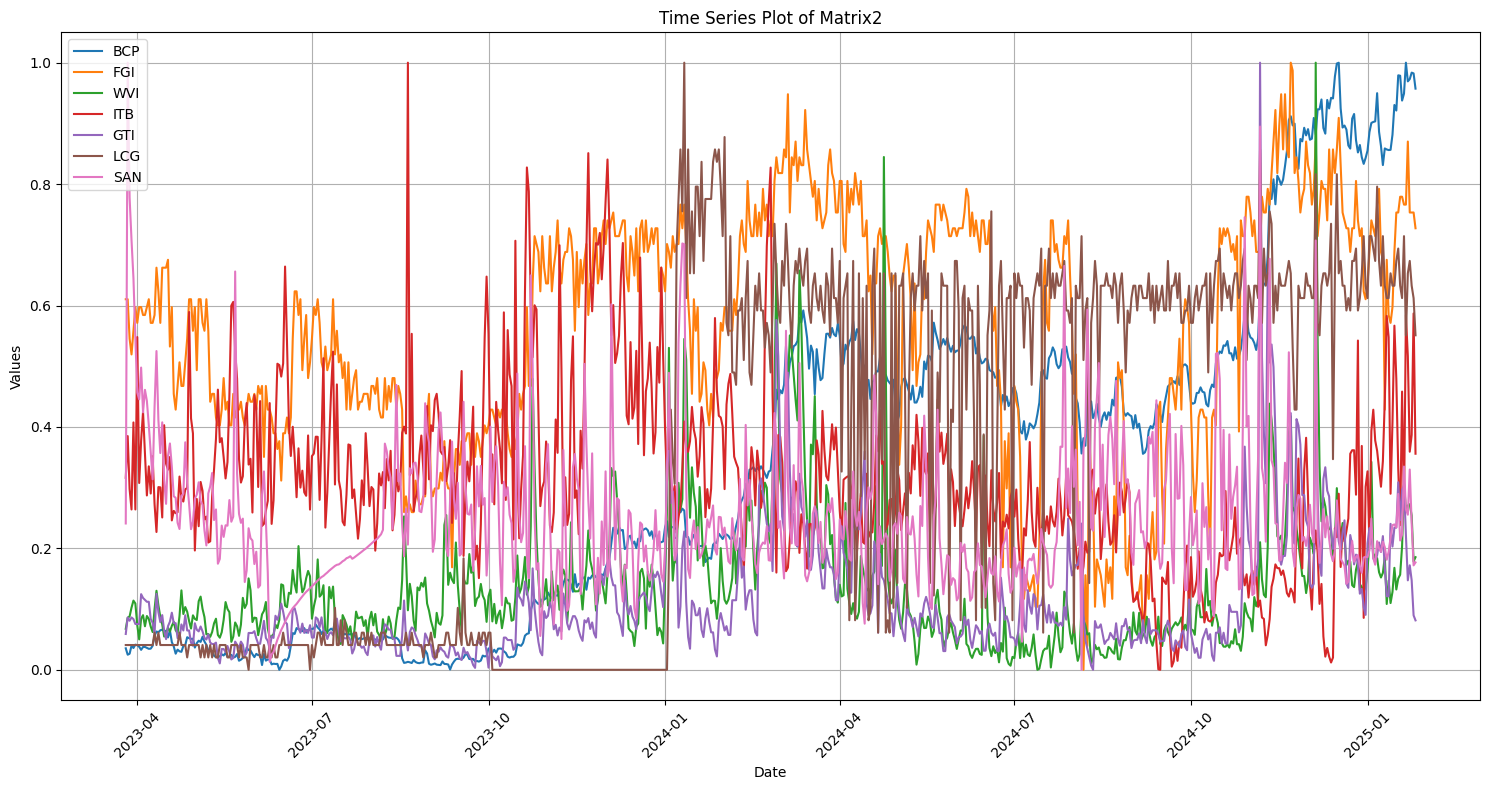

In [ ]:
# prompt: make the plots start 2023-03-26 and fit all the plots in a single graph

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns # Import the seaborn library and assign it the alias 'sns'
from IPython import get_ipython
from IPython.display import display
from google.colab import files


# Filter data starting from 2023-03-26
start_date = pd.to_datetime('2023-03-26')
matrix2_filtered = matrix2[matrix2['date'] >= start_date]


# Plotting all columns in a single graph
plt.figure(figsize=(15, 8))  # Adjust figure size as needed

for col in matrix2_filtered.columns[1:]:
    plt.plot(matrix2_filtered['date'], matrix2_filtered[col], label=col)

plt.xlabel('Date')
plt.ylabel('Values')
plt.title('Time Series Plot of Matrix2')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()


## Descriptive statistics

In [ ]:
#Remove the date column before calculating descriptive statistics
matrix2_no_date = matrix2.drop(columns=['date'])

# Calculate descriptive statistics without the date column
descriptive_stats = matrix2_no_date.describe()

descriptive_stats

,BCP,FGI,WVI,ITB,GTI,LCG,SAN
count,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000
mean,0.338572,0.567573,0.136931,0.315272,0.113437,0.351912,0.250252
std,0.278940,0.195046,0.110552,0.144589,0.099623,0.300998,0.119173
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.057279,0.428571,0.067517,0.230212,0.052812,0.040816,0.176322
50%,0.335222,0.610390,0.109252,0.297491,0.078688,0.469388,0.225505
75%,0.513264,0.727273,0.167303,0.378496,0.144843,0.632653,0.297509
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Normality test

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns # Import the seaborn library and assign it the alias 'sns'
from IPython import get_ipython
from IPython.display import display
from google.colab import files
from scipy.stats import shapiro

#Remove the date column before calculating descriptive statistics
matrix2_no_date = matrix2.drop(columns=['date'])

# Calculate descriptive statistics without the date column
descriptive_stats = matrix2_no_date.describe()

descriptive_stats

# Perform normality test for each variable
for column in matrix2_no_date.columns:
  stat, p = shapiro(matrix2_no_date[column])
  print(f"Variable: {column}")
  print(f"Shapiro-Wilk Test Statistic: {stat}")
  print(f"P-value: {p}")
  if p > 0.05:
    print("The data is likely normally distributed.")
  else:
    print("The data is likely not normally distributed.")
  print("-" * 20)


Variable: BCP
Shapiro-Wilk Test Statistic: 0.8994427188608474
P-value: 1.348871598110338e-20
The data is likely not normally distributed.
--------------------
Variable: FGI
Shapiro-Wilk Test Statistic: 0.9602679512962532
P-value: 1.5987891617543767e-12
The data is likely not normally distributed.
--------------------
Variable: WVI
Shapiro-Wilk Test Statistic: 0.7863196513288085
P-value: 9.154851609140058e-29
The data is likely not normally distributed.
--------------------
Variable: ITB
Shapiro-Wilk Test Statistic: 0.9521716829357993
P-value: 5.836018167684651e-14
The data is likely not normally distributed.
--------------------
Variable: GTI
Shapiro-Wilk Test Statistic: 0.754928044770167
P-value: 2.090726199305998e-30
The data is likely not normally distributed.
--------------------
Variable: LCG
Shapiro-Wilk Test Statistic: 0.7875425843311773
P-value: 1.0698744282779451e-28
The data is likely not normally distributed.
--------------------
Variable: SAN
Shapiro-Wilk Test Statistic: 0.

## Scatterplots

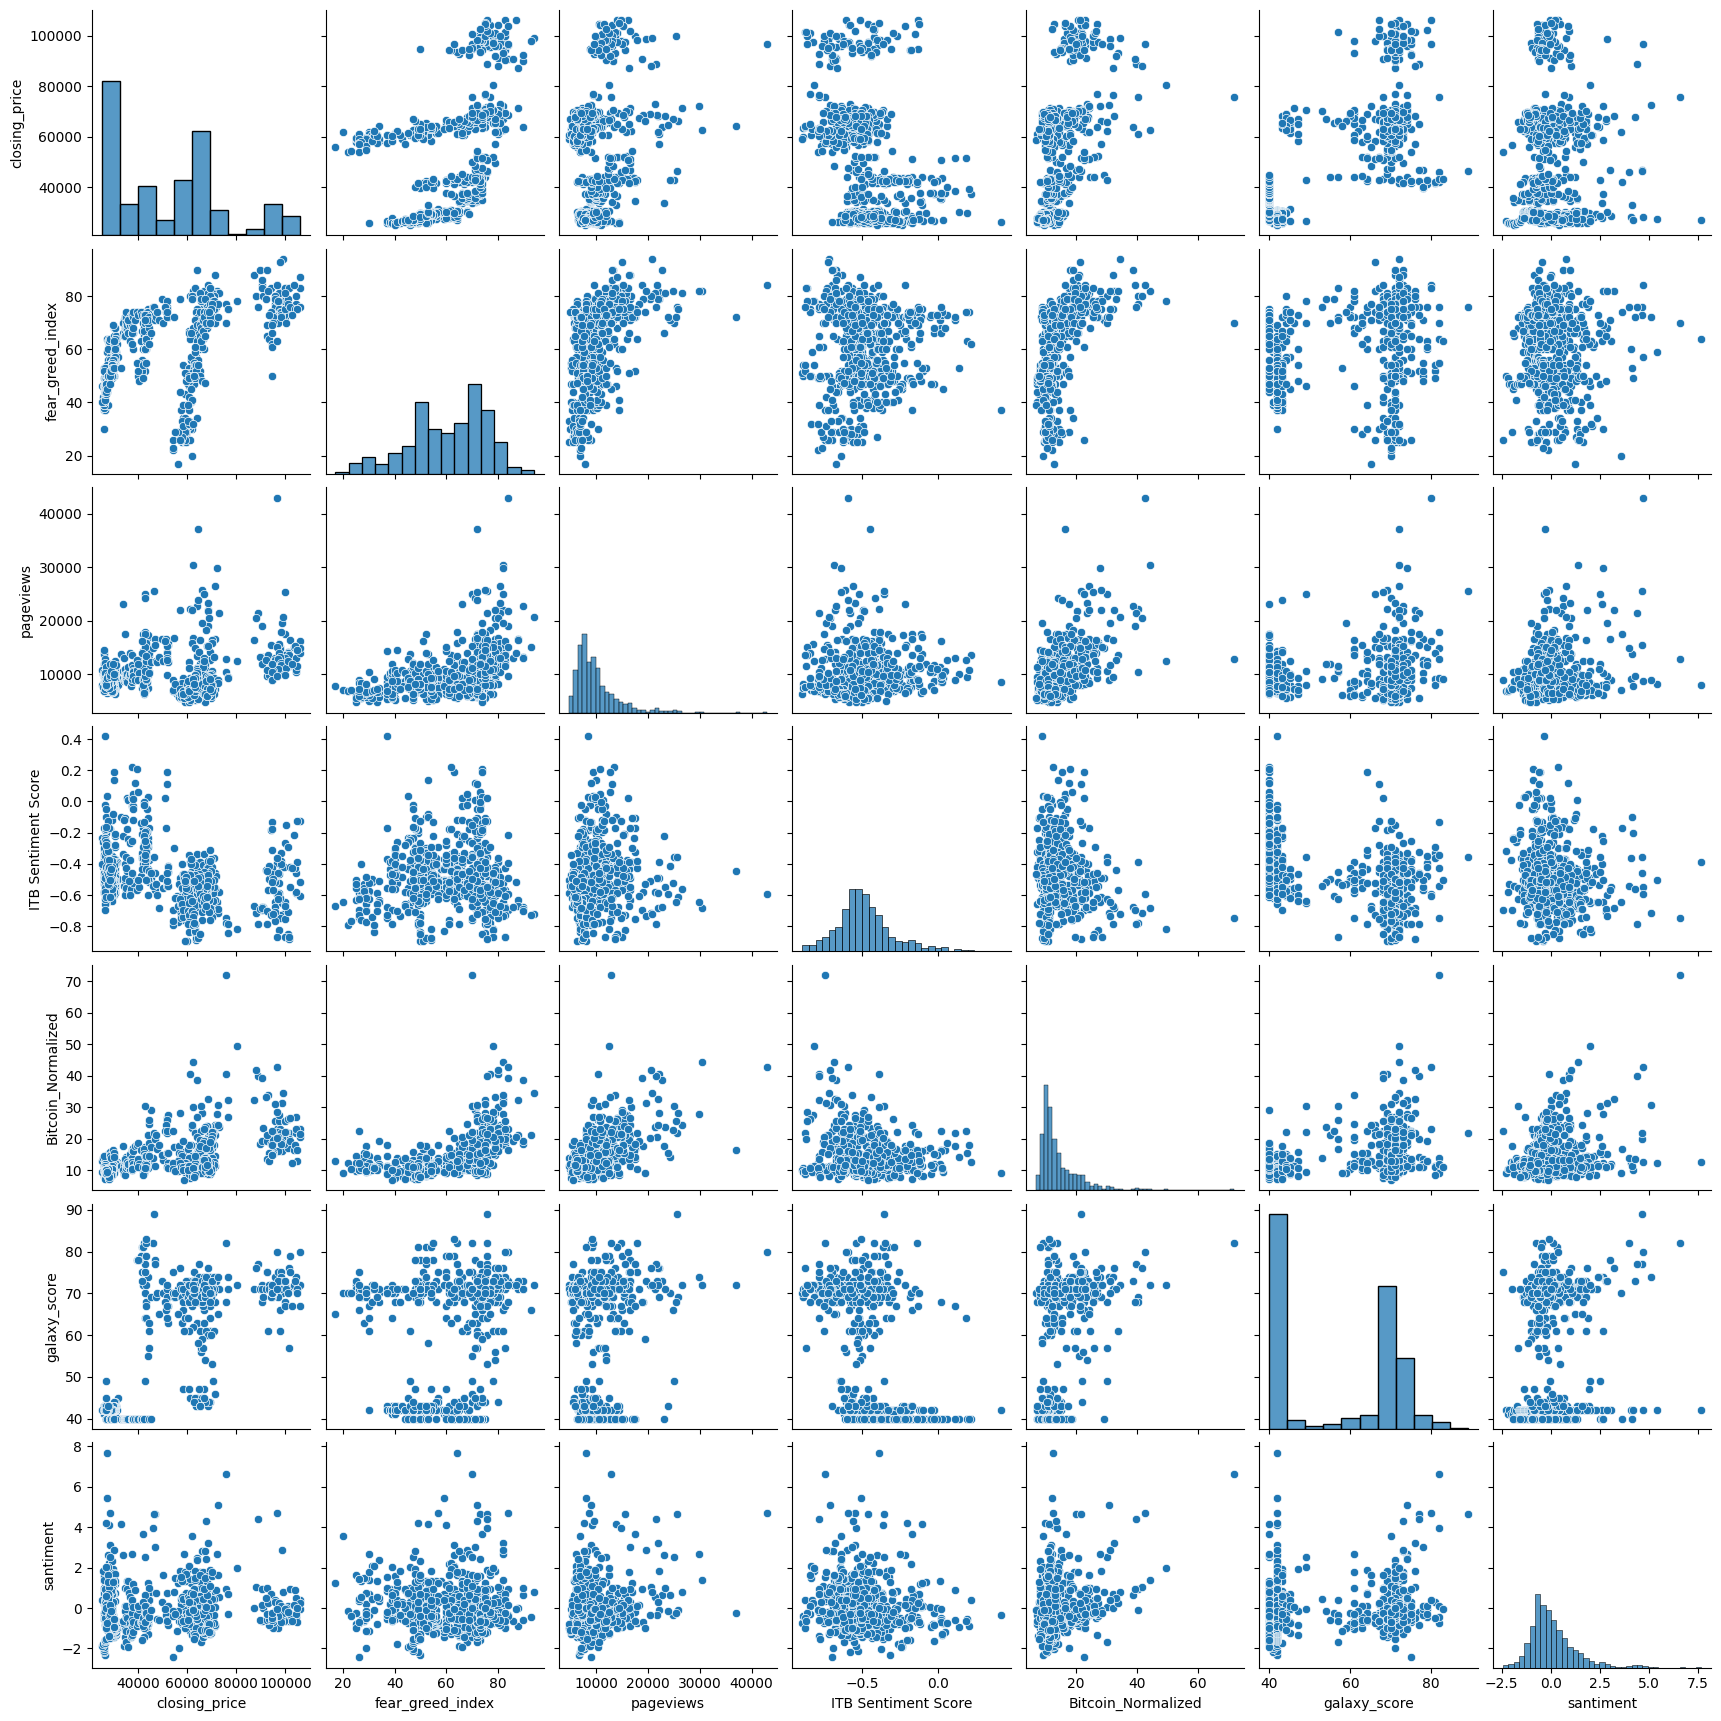

In [ ]:
# prompt: do pairwise scatterplot in a matrix setting

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'matrix2_no_date' DataFrame is already loaded and has the data without the date column

# Create the pairwise scatterplot matrix
sns.pairplot(matrix2_no_date)
plt.show()


# PCA INDEX

In [ ]:
matrix2_filtered = matrix2

In [ ]:
# prompt: use PCA to create from the colunmns of matrix2 excludinc the date an optimal sentiment index to predict the closing price

import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Assuming matrix2_filtered is your DataFrame with normalized data and 'date' column
# and 'closing_price' is the column you want to predict

# Separate features (excluding date and closing price) and target variable
features = matrix2_filtered.drop(columns=['date', 'closing_price'])
target = matrix2_filtered['closing_price']

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Apply PCA
pca = PCA(n_components=1)  # Reduce to one principal component
sentiment_index = pca.fit_transform(scaled_features)

In [ ]:
# Create a new DataFrame with the sentiment index and closing price
pca_df = pd.DataFrame({'sentiment_index': sentiment_index.flatten(), 'closing_price': target})

# Now you have a DataFrame with a single sentiment index that can be used to predict closing prices
print(pca_df.head())

   sentiment_index  closing_price
0        -0.935184   27994.330078
1         0.434370   27139.888672
2         0.008525   27268.130859
3        -0.028704   28348.441406
4        -0.166344   28033.562500


In [ ]:
# You can further use this DataFrame for regression analysis or other predictive models.
# Example: using linear regression
from sklearn.linear_model import LinearRegression

X = pca_df[['sentiment_index']]
y = pca_df['closing_price']

model = LinearRegression()
model.fit(X, y)

print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_}")

# Now you can predict closing prices using the model and the sentiment index
# predicted_closing_price = model.predict(new_sentiment_index)

In [ ]:
# prompt: add the sentiment_index column to matrix2

# Add the sentiment_index to matrix2
matrix2['sentiment_index'] = pca_df['sentiment_index']
print(matrix2.head())

        date  closing_price  fear_greed_index  pageviews  ITB Sentiment Score  \
0 2023-03-26   27994.330078              64.0       7367            -0.480679   
1 2023-03-27   27139.888672              64.0       8056            -0.390391   
2 2023-03-28   27268.130859              59.0       8152            -0.505090   
3 2023-03-29   28348.441406              57.0       8703            -0.549226   
4 2023-03-30   28033.562500              60.0       9144            -0.360882   

   Bitcoin_Normalized  galaxy_score  santiment  sentiment_index  
0           10.847403            42   0.000000        -0.935184  
1           12.613497            42   7.682213         0.434370  
2           12.263122            42   5.432307         0.008525  
3           12.613497            42   4.723539        -0.028704  
4           12.438309            42   4.090893        -0.166344  


# Step 2: Correlation analysis

## Pearson correlation

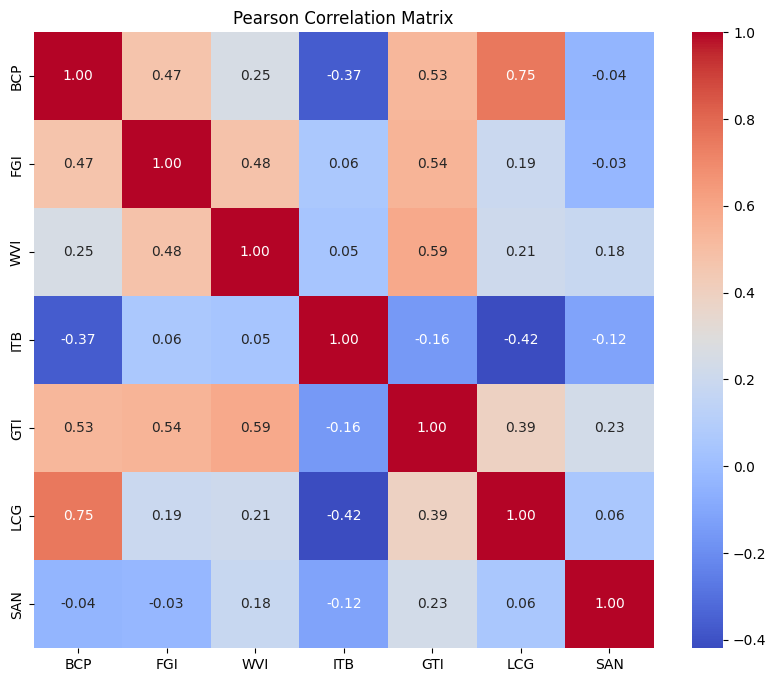

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming matrix2 is your DataFrame and it has a 'date' column
# Remove the 'date' column
matrix2_no_date = matrix2.drop('date', axis=1)

# Calculate the Pearson correlation
correlation_matrix = matrix2_no_date.corr(method='pearson')

# Display the correlation matrix
#print(correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Pearson Correlation Matrix')
plt.show()

### Significance of the Pearson correlations with Bitcoin prices

In [ ]:
from scipy.stats import pearsonr # Import the pearsonr function

# prompt: include the significance of the correlations only for the closing_price

# Significance of correlations for closing_price only

# Assuming matrix2 is your DataFrame and it has a 'date' column
# Remove the 'date' column
matrix2_no_date = matrix2.drop('date', axis=1)

# Calculate the Pearson correlation
correlation_matrix = matrix2_no_date.corr(method='pearson')

# Get correlations with closing_price
closing_price_correlations = correlation_matrix['BCP'].drop('BCP')

# Iterate through the correlations with closing_price
for col in closing_price_correlations.index:
    correlation_coefficient = closing_price_correlations[col]
    # Perform Pearson correlation test to get p-value
    t_stat, p_value = pearsonr(matrix2_no_date['BCP'], matrix2_no_date[col])

    print(f"Correlation between BCP and {col}: {correlation_coefficient:.2f}")
    print(f"  P-value: {p_value:.3f}")
    if p_value < 0.05:
        print("  Correlation is statistically significant (p < 0.05)")
    else:
        print("  Correlation is not statistically significant (p >= 0.05)")
    print("-" * 20)


Correlation between BCP and FGI: 0.47
  P-value: 0.000
  Correlation is statistically significant (p < 0.05)
--------------------
Correlation between BCP and WVI: 0.25
  P-value: 0.000
  Correlation is statistically significant (p < 0.05)
--------------------
Correlation between BCP and ITB: -0.37
  P-value: 0.000
  Correlation is statistically significant (p < 0.05)
--------------------
Correlation between BCP and GTI: 0.53
  P-value: 0.000
  Correlation is statistically significant (p < 0.05)
--------------------
Correlation between BCP and LCG: 0.75
  P-value: 0.000
  Correlation is statistically significant (p < 0.05)
--------------------
Correlation between BCP and SAN: -0.04
  P-value: 0.338
  Correlation is not statistically significant (p >= 0.05)
--------------------


### Pearson correlation in rolling windows

In [ ]:
# prompt: apply pearson correlations of the other colums of matrix two with BCP in rolling windows to see how it varies over time

# Assuming 'matrix2' DataFrame is already loaded and processed as in the previous code.

import pandas as pd
from scipy.stats import pearsonr

# Define the rolling window size
window_size = 30  # Example: 30-day rolling window

# Function to calculate rolling Pearson correlation
def rolling_pearson(df, column1, column2, window):
    correlations = []
    p_values = []
    for i in range(window - 1, len(df)):
        window_data = df.iloc[i - window + 1:i + 1]
        corr, p_val = pearsonr(window_data[column1], window_data[column2])
        correlations.append(corr)
        p_values.append(p_val)
    return correlations, p_values


# Calculate rolling correlations for each column with 'BCP'
rolling_correlations = {}
for col in matrix2.columns:
    if col != 'BCP' and col != 'date':  # Exclude 'BCP' and 'date' columns
      correlations, p_values = rolling_pearson(matrix2, 'BCP', col, window_size)
      rolling_correlations[col] = {'correlation': correlations, 'p_value': p_values}

# Create a DataFrame from the rolling correlations
rolling_correlations_df = pd.DataFrame(rolling_correlations)

# Print the resulting DataFrame or use it for further analysis
print(rolling_correlations_df.head())


<ipython-input-14-0144062f73f3>:17: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_val = pearsonr(window_data[column1], window_data[column2])


                                                           FGI  \
correlation  [0.5522642681921309, 0.5606396483887154, 0.612...   
p_value      [0.0015546579513719726, 0.0012707965028449823,...   

                                                           WVI  \
correlation  [-0.04650079946776547, -0.06681876818709608, -...   
p_value      [0.8072271223658505, 0.7257212951862406, 0.707...   

                                                           ITB  \
correlation  [-0.09337239502157374, -0.08768387466178085, -...   
p_value      [0.6235926275102888, 0.6449805766111699, 0.835...   

                                                           GTI  \
correlation  [-0.05992718847449706, -0.07545427445663386, -...   
p_value      [0.7530878881006666, 0.691894846305757, 0.6960...   

                                                           LCG  \
correlation  [0.15418670774892457, 0.1516134782059201, 0.14...   
p_value      [0.41592434412746343, 0.4238413588065215, 0.45...   

     

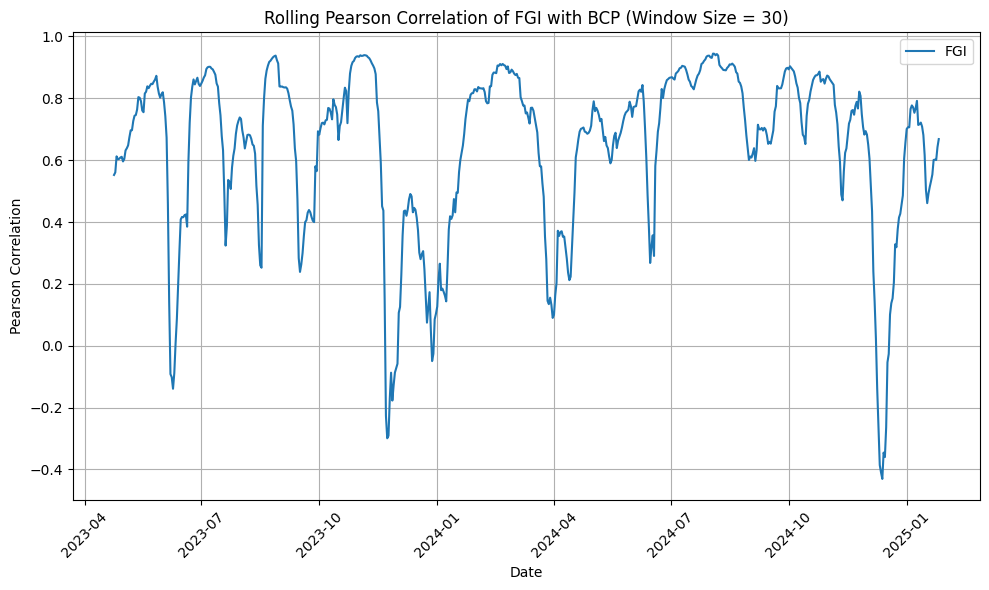

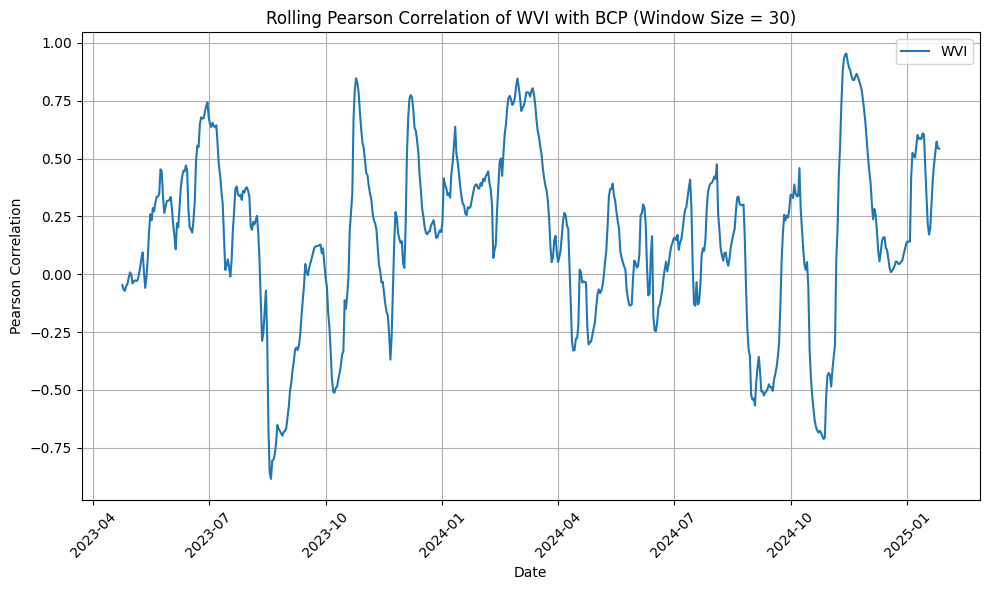

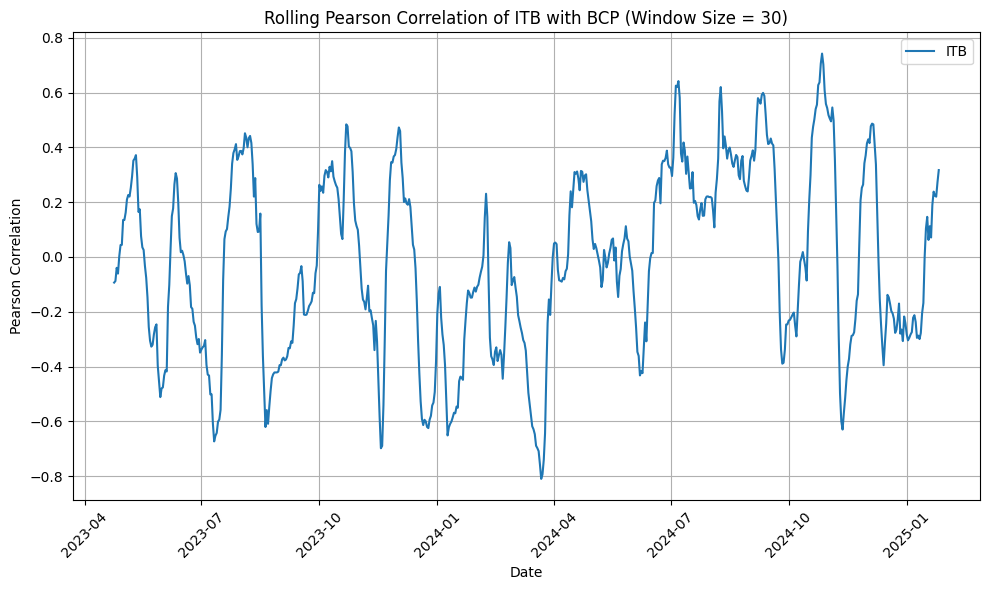

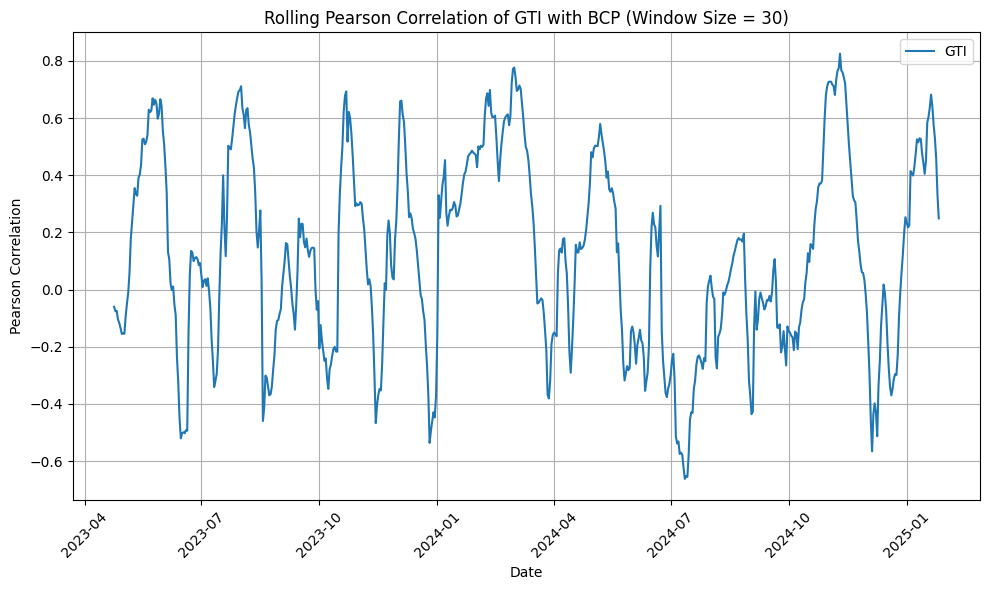

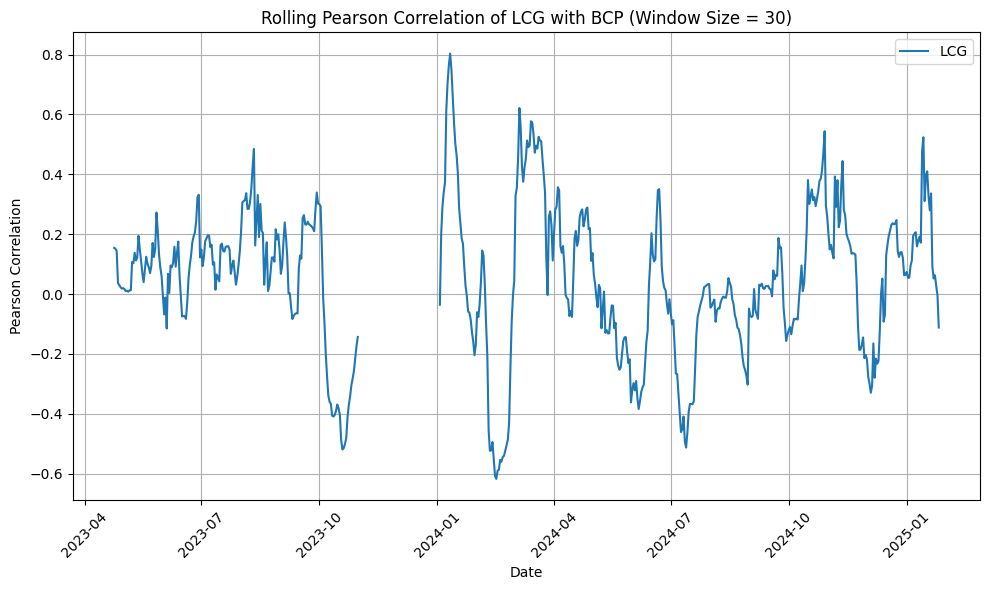

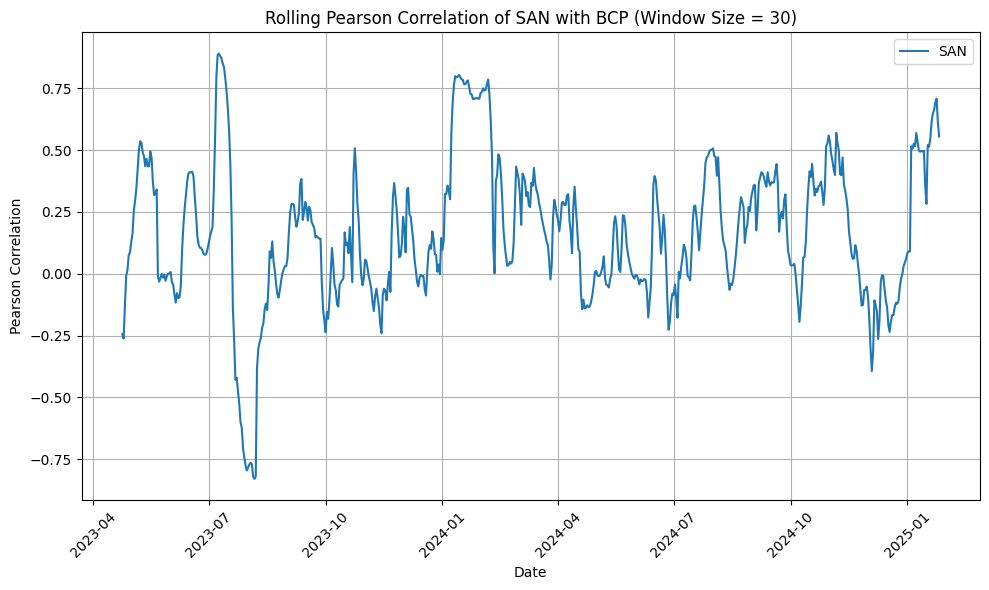

In [ ]:
# prompt: apply pearson correlations of the other colums of matrix two with BCP in rolling windows to see how it varies over time and plot the results in different graphs

# Assuming 'matrix2' DataFrame and 'rolling_correlations_df' are already defined as in the previous code.

# Plotting the rolling correlations for each column in separate graphs
for col in rolling_correlations_df.columns:
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.plot(matrix2['date'][window_size - 1:], rolling_correlations_df[col]['correlation'], label=col)
    plt.xlabel('Date')
    plt.ylabel('Pearson Correlation')
    plt.title(f'Rolling Pearson Correlation of {col} with BCP (Window Size = {window_size})')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## Spearmann correlation

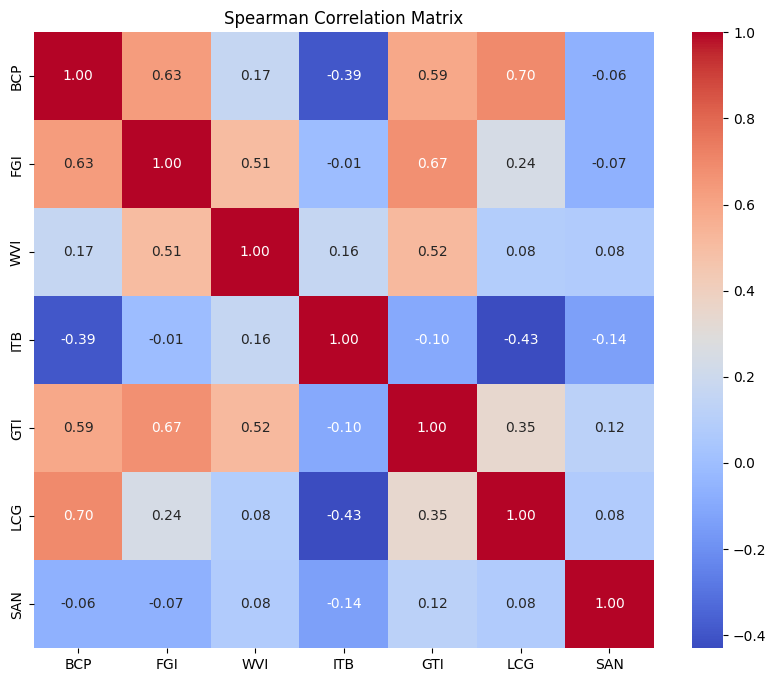

In [ ]:
# prompt: do the spearmann correlation on matrix2 excluding the date

# Assuming matrix2 is your DataFrame and it has a 'date' column
# Remove the 'date' column
matrix2_no_date = matrix2.drop('date', axis=1)

# Calculate the Spearman correlation
spearman_correlation_matrix = matrix2_no_date.corr(method='spearman')

# Display the correlation matrix
#print(spearman_correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Spearman Correlation Matrix')
plt.show()


## Kendall correlation

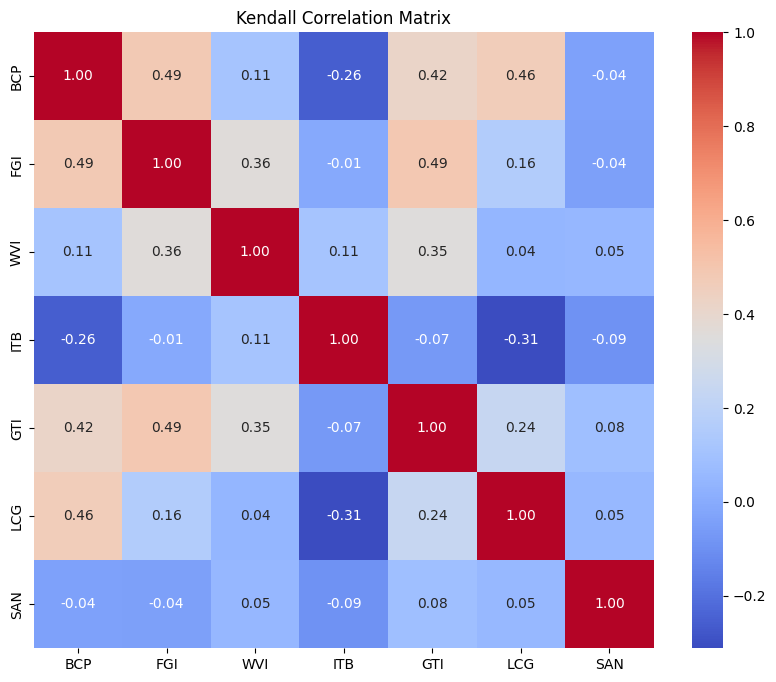

In [ ]:
# prompt:  do the kendall correlation on matrix2 excluding the date

from scipy.stats import kendalltau

# Assuming matrix2 is your DataFrame and it has a 'date' column
# Remove the 'date' column
matrix2_no_date = matrix2.drop('date', axis=1)

# Calculate the Kendall correlation matrix
kendall_correlation_matrix = matrix2_no_date.corr(method=lambda x, y: kendalltau(x, y)[0])

# Display the Kendall correlation matrix
#print(kendall_correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(kendall_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Kendall Correlation Matrix')
plt.show()


## Distance correlation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 3.9 MB/s eta 0:00:00


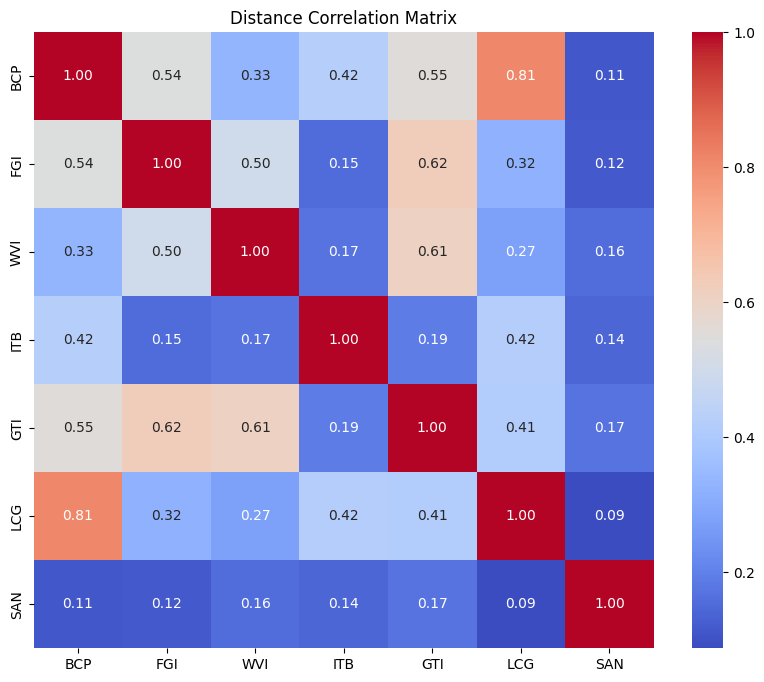

In [ ]:
# prompt: do the distance correlation on matrix2 excluding the date

!pip install dcor

import pandas as pd
from dcor import distance_correlation

# Assuming matrix2 is your DataFrame and it has a 'date' column
# Remove the 'date' column
matrix2_no_date = matrix2.drop('date', axis=1)

# Calculate the distance correlation matrix
distance_correlation_matrix = matrix2_no_date.corr(method=lambda x, y: distance_correlation(x, y))

# Display the distance correlation matrix
#print(distance_correlation_matrix)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(distance_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Distance Correlation Matrix')
plt.show()

                     closing_price  fear_greed_index  pageviews  \
closing_price             1.000000          0.551671   0.210730   
fear_greed_index          0.551671          1.000000   0.491568   
pageviews                 0.210730          0.491568   1.000000   
ITB Sentiment Score      -0.378614          0.026711   0.104736   
Bitcoin_Normalized        0.559048          0.605062   0.553022   
galaxy_score              0.724300          0.216391   0.146546   
santiment                -0.050526         -0.047072   0.128011   

                     ITB Sentiment Score  Bitcoin_Normalized  galaxy_score  \
closing_price                  -0.378614            0.559048      0.724300   
fear_greed_index                0.026711            0.605062      0.216391   
pageviews                       0.104736            0.553022      0.146546   
ITB Sentiment Score             1.000000           -0.128385     -0.425129   
Bitcoin_Normalized             -0.128385            1.000000      0.36894

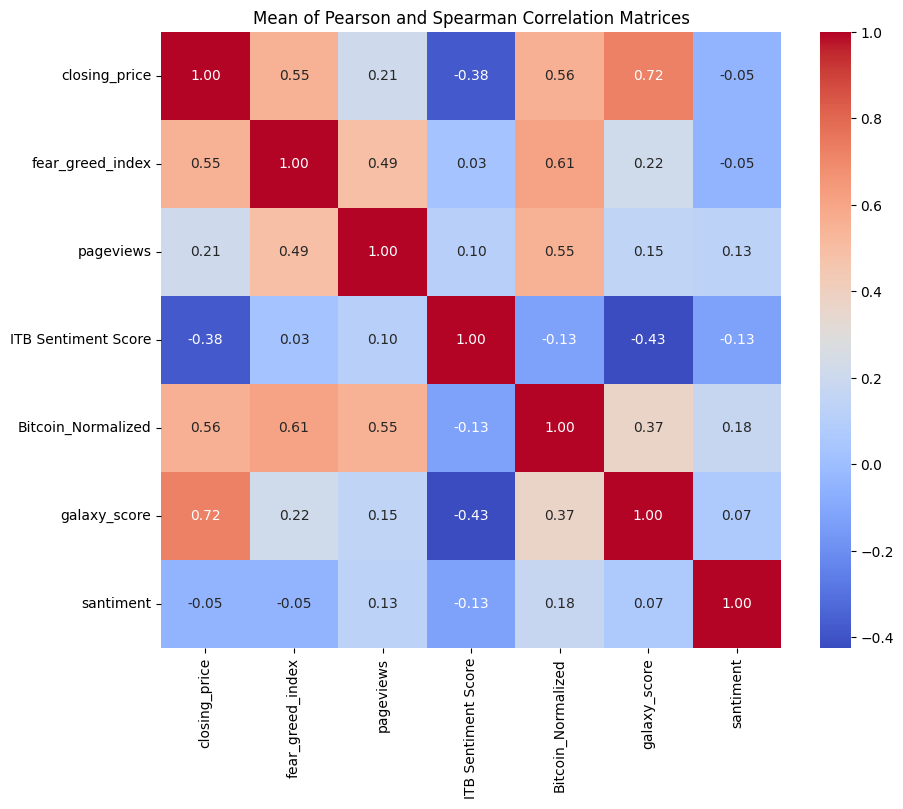

In [ ]:
# prompt: do the mean of pearson and spearmann correlation matrixes

# Calculate the mean of the Pearson and Spearman correlation matrices
mean_correlation_matrix = (correlation_matrix + spearman_correlation_matrix) / 2

# Display the mean correlation matrix
print(mean_correlation_matrix)

# Plot the heatmap for the mean correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(mean_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mean of Pearson and Spearman Correlation Matrices')
plt.show()


## Absolute difference between Pearson and Spearmann measures

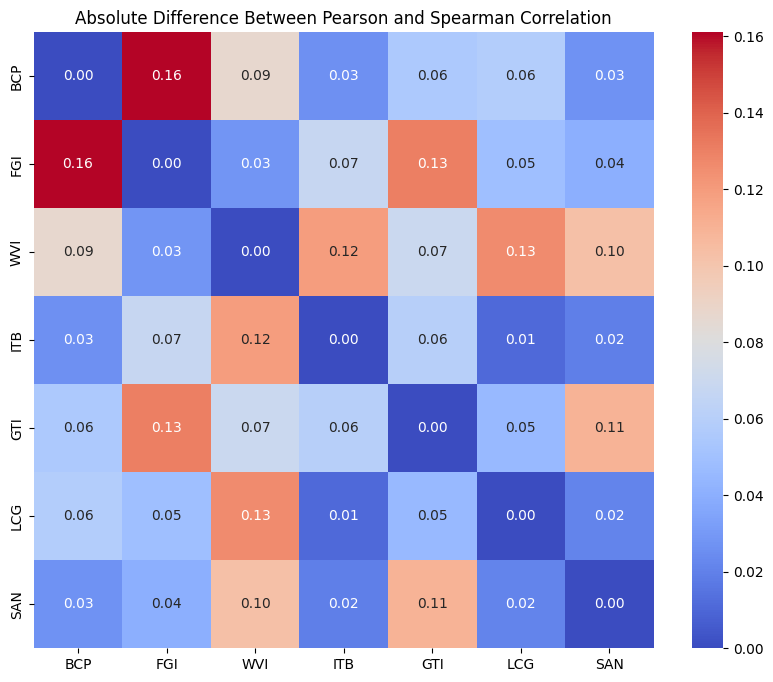

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the absolute difference between Pearson and Spearman correlation matrices
correlation_difference = abs(correlation_matrix - spearman_correlation_matrix)

# Display the difference matrix
#print(correlation_difference)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_difference, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Absolute Difference Between Pearson and Spearman Correlation')
plt.show()

In [ ]:
import numpy as np  # Import NumPy library

In [ ]:
# prompt: define matrix2_no_date as matrix without the date column

# matrix2_no_date is already defined in the provided code.
# No further code is needed to define it.  The following is for demonstration and
# can be removed if you don't need a separate definition
matrix2_no_date = matrix2.drop(columns=['date'])

## Normality and Stationarity tests

In [ ]:
# prompt: do normality and stationarity tests to the columns of matrix2
from statsmodels.tsa.stattools import adfuller
from scipy.stats import shapiro

def normality_test(data):
    stat, p = shapiro(data)
    return stat, p

def stationarity_test(data):
    result = adfuller(data)
    return result[0], result[1], result[4]['5%']

for col in matrix2_no_date.columns:
    print(f"--- {col} ---")

    #Normality Test
    normality_stat, normality_p = normality_test(matrix2_no_date[col])
    print(f"Shapiro-Wilk Normality Test: Statistic={normality_stat:.3f}, p={normality_p:.3f}")
    if normality_p > 0.05:
        print("Sample looks Gaussian (fail to reject H0)")
    else:
        print("Sample does not look Gaussian (reject H0)")

    #Stationarity Test
    stationarity_stat, stationarity_p, critical_value = stationarity_test(matrix2_no_date[col])
    print(f"ADF Stationarity Test: Statistic={stationarity_stat:.3f}, p={stationarity_p:.3f}, Critical Value (5%)= {critical_value:.3f}")
    if stationarity_p <= 0.05 and stationarity_stat < critical_value:
        print("Time series is stationary (reject H0)")
    else:
        print("Time series is non-stationary (fail to reject H0)")
    print()

--- BCP ---
Shapiro-Wilk Normality Test: Statistic=0.899, p=0.000
Sample does not look Gaussian (reject H0)
ADF Stationarity Test: Statistic=0.478, p=0.984, Critical Value (5%)= -2.866
Time series is non-stationary (fail to reject H0)

--- FGI ---
Shapiro-Wilk Normality Test: Statistic=0.960, p=0.000
Sample does not look Gaussian (reject H0)
ADF Stationarity Test: Statistic=-3.768, p=0.003, Critical Value (5%)= -2.866
Time series is stationary (reject H0)

--- WVI ---
Shapiro-Wilk Normality Test: Statistic=0.786, p=0.000
Sample does not look Gaussian (reject H0)
ADF Stationarity Test: Statistic=-3.998, p=0.001, Critical Value (5%)= -2.866
Time series is stationary (reject H0)

--- ITB ---
Shapiro-Wilk Normality Test: Statistic=0.952, p=0.000
Sample does not look Gaussian (reject H0)
ADF Stationarity Test: Statistic=-4.357, p=0.000, Critical Value (5%)= -2.866
Time series is stationary (reject H0)

--- GTI ---
Shapiro-Wilk Normality Test: Statistic=0.755, p=0.000
Sample does not look Ga

In [ ]:
# prompt: take the first differences of matrix2_no_date and retry the previous tests

# Calculate the first difference for each column
matrix2_diff = matrix2_no_date.diff().dropna()

# Normality and Stationarity Tests on Differenced Data
def normality_test(data):
    stat, p = shapiro(data)
    return stat, p

def stationarity_test(data):
    result = adfuller(data)
    return result[0], result[1], result[4]['5%']

for col in matrix2_diff.columns:
    print(f"--- {col} (Differenced) ---")

    #Normality Test
    normality_stat, normality_p = normality_test(matrix2_diff[col])
    print(f"Shapiro-Wilk Normality Test: Statistic={normality_stat:.3f}, p={normality_p:.3f}")
    if normality_p > 0.05:
        print("Sample looks Gaussian (fail to reject H0)")
    else:
        print("Sample does not look Gaussian (reject H0)")

    #Stationarity Test
    stationarity_stat, stationarity_p, critical_value = stationarity_test(matrix2_diff[col])
    print(f"ADF Stationarity Test: Statistic={stationarity_stat:.3f}, p={stationarity_p:.3f}, Critical Value (5%)= {critical_value:.3f}")
    if stationarity_p <= 0.05 and stationarity_stat < critical_value:
        print("Time series is stationary (reject H0)")
    else:
        print("Time series is non-stationary (fail to reject H0)")
    print()


--- BCP (Differenced) ---
Shapiro-Wilk Normality Test: Statistic=0.916, p=0.000
Sample does not look Gaussian (reject H0)
ADF Stationarity Test: Statistic=-27.380, p=0.000, Critical Value (5%)= -2.866
Time series is stationary (reject H0)

--- FGI (Differenced) ---
Shapiro-Wilk Normality Test: Statistic=0.937, p=0.000
Sample does not look Gaussian (reject H0)
ADF Stationarity Test: Statistic=-17.673, p=0.000, Critical Value (5%)= -2.866
Time series is stationary (reject H0)

--- WVI (Differenced) ---
Shapiro-Wilk Normality Test: Statistic=0.695, p=0.000
Sample does not look Gaussian (reject H0)
ADF Stationarity Test: Statistic=-10.842, p=0.000, Critical Value (5%)= -2.866
Time series is stationary (reject H0)

--- ITB (Differenced) ---
Shapiro-Wilk Normality Test: Statistic=0.936, p=0.000
Sample does not look Gaussian (reject H0)
ADF Stationarity Test: Statistic=-12.654, p=0.000, Critical Value (5%)= -2.866
Time series is stationary (reject H0)

--- GTI (Differenced) ---
Shapiro-Wilk N

## Time-Lagged Correlation

In [ ]:
import statsmodels.tsa.stattools as ts

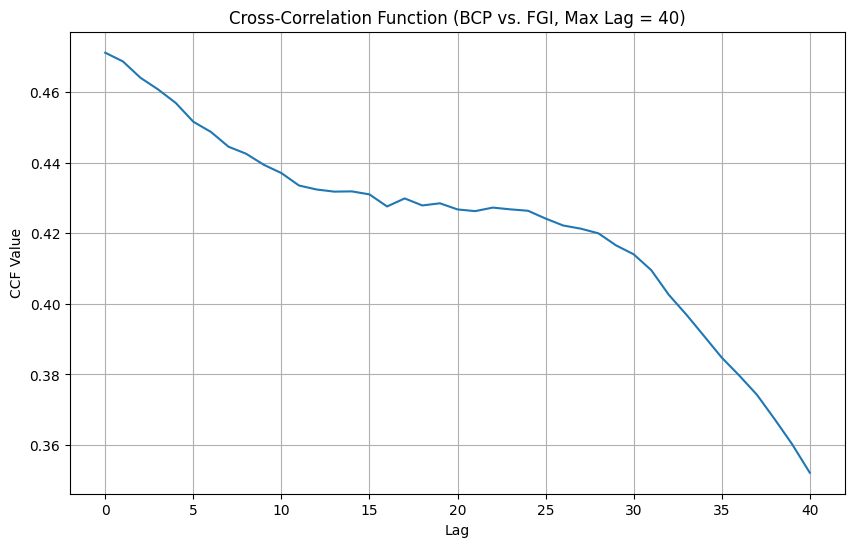

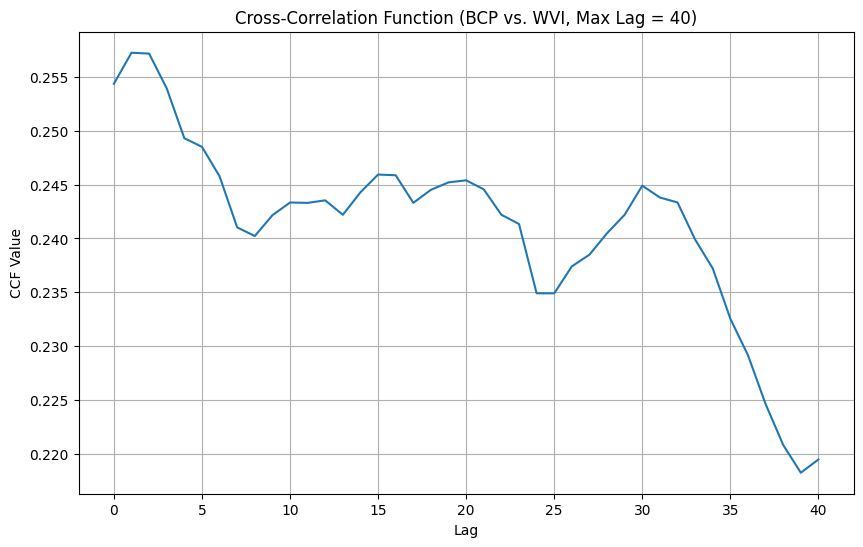

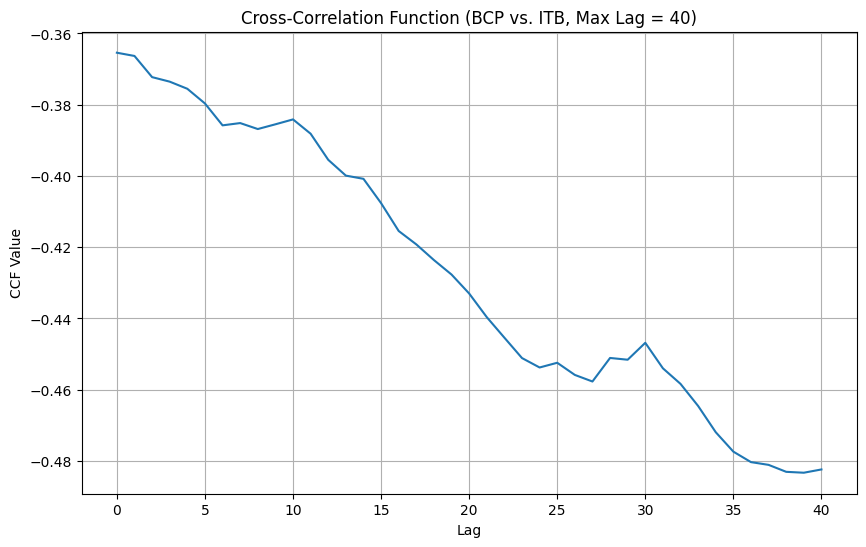

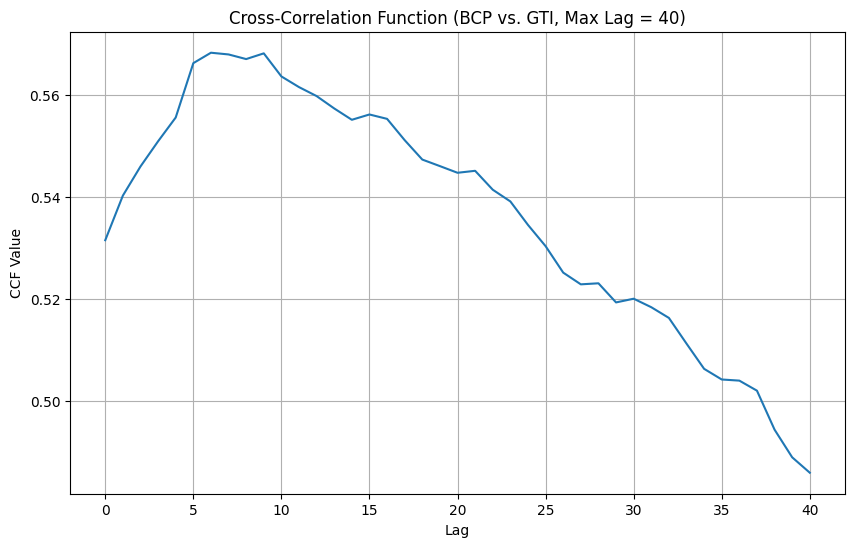

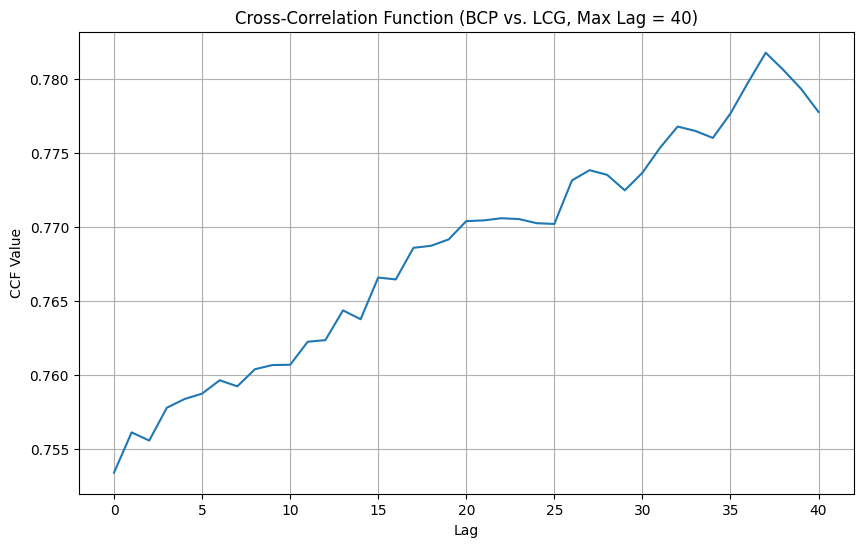

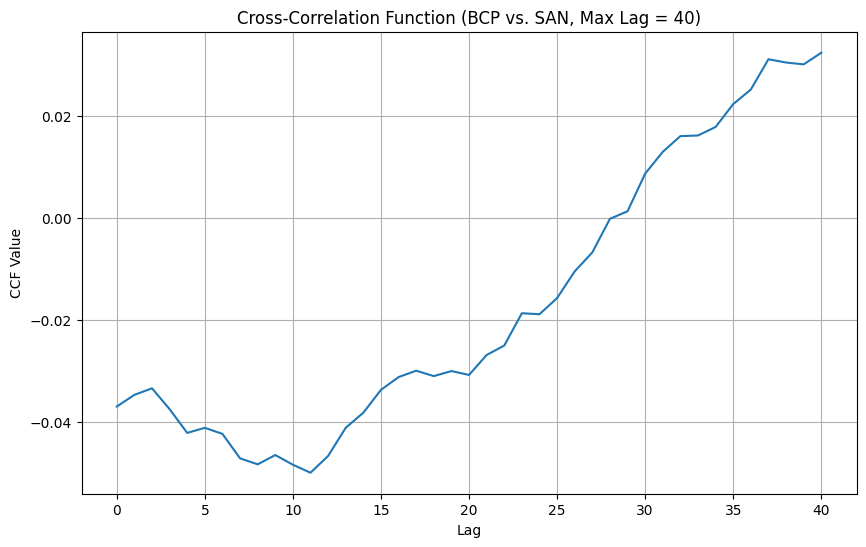

In [ ]:
# prompt: do the time lagged correlations with closing_price for all the colums in matrix2 except the date

from scipy.stats import pearsonr
import statsmodels.tsa.stattools as ts
import matplotlib.pyplot as plt

# Assuming matrix2 and matrix2_no_date are already defined from the previous code

def time_lagged_correlation(df, target_column):
    """
    Calculates and plots time-lagged correlations for each column in df with target_column.
    """
    for col in df.columns:
        if col != target_column: # Skip the target column itself
            ccf_values = ts.ccf(df[target_column], df[col])
            plt.figure(figsize=(10, 6))
            plt.plot(ccf_values[:41])  # Plot lags from 0 to 20
            plt.xlabel('Lag')
            plt.ylabel('CCF Value')
            plt.title(f'Cross-Correlation Function ({target_column} vs. {col}, Max Lag = 40)')
            plt.grid(True)
            plt.show()

# Call the function with 'closing_price' as the target column
time_lagged_correlation(matrix2_no_date, 'BCP')

In [ ]:
# prompt: interpret the results of the ccf of previous code starting from time_lagged_correlation(matrix2_no_date, 'BCP')
import numpy as np # Add this line to import NumPy

def interpret_ccf(df, target_column):
    """
    Interprets the results of the cross-correlation function (CCF).
    """
    for col in df.columns:
        if col != target_column:
            ccf_values = ts.ccf(df[target_column], df[col])
            max_ccf = np.max(ccf_values)
            lag_of_max_ccf = np.argmax(ccf_values)

            print(f"--- {target_column} vs. {col} ---")
            print(f"Maximum CCF value: {max_ccf:.3f}")
            print(f"Lag at which maximum CCF occurs: {lag_of_max_ccf}")

            if max_ccf > 0.5 : # Example threshold, adjust as needed
                print(f"Significant positive correlation at lag {lag_of_max_ccf}")
                if lag_of_max_ccf > 0:
                    print(f"{col} leads {target_column} by {lag_of_max_ccf} periods")
                elif lag_of_max_ccf < 0 :
                    print(f"{target_column} leads {col} by {-lag_of_max_ccf} periods")
                else:
                  print(f"{col} and {target_column} are highly correlated at the same time")
            elif max_ccf < -0.5: # Example threshold, adjust as needed
                print(f"Significant negative correlation at lag {lag_of_max_ccf}")
                if lag_of_max_ccf > 0:
                    print(f"{col} leads {target_column} by {lag_of_max_ccf} periods")
                elif lag_of_max_ccf < 0 :
                    print(f"{target_column} leads {col} by {-lag_of_max_ccf} periods")
                else:
                  print(f"{col} and {target_column} are highly negatively correlated at the same time")
            else:
                print("No significant correlation found.")
            print("-" * 20)

interpret_ccf(matrix2_no_date, 'BCP')

--- BCP vs. FGI ---
Maximum CCF value: 0.497
Lag at which maximum CCF occurs: 671
No significant correlation found.
--------------------
--- BCP vs. WVI ---
Maximum CCF value: 0.513
Lag at which maximum CCF occurs: 276
Significant positive correlation at lag 276
WVI leads BCP by 276 periods
--------------------
--- BCP vs. ITB ---
Maximum CCF value: 0.767
Lag at which maximum CCF occurs: 391
Significant positive correlation at lag 391
ITB leads BCP by 391 periods
--------------------
--- BCP vs. GTI ---
Maximum CCF value: 0.568
Lag at which maximum CCF occurs: 6
Significant positive correlation at lag 6
GTI leads BCP by 6 periods
--------------------
--- BCP vs. LCG ---
Maximum CCF value: 0.782
Lag at which maximum CCF occurs: 37
Significant positive correlation at lag 37
LCG leads BCP by 37 periods
--------------------
--- BCP vs. SAN ---
Maximum CCF value: 8.288
Lag at which maximum CCF occurs: 669
Significant positive correlation at lag 669
SAN leads BCP by 669 periods
-------------

Risultati assurdi...............

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def time_lagged_correlation_full(df, target_column, max_lag=20):
    """
    Computes and plots time-lagged Pearson correlations from -max_lag to +max_lag
    between the target column and all other columns in the DataFrame.
    """
    target = df[target_column]
    target = (target - target.mean()) / target.std()  # Normalize target

    for col in df.columns:
        if col == target_column:
            continue
        series = (df[col] - df[col].mean()) / df[col].std()  # Normalize

        lags = range(-max_lag, max_lag + 1)
        correlations = []

        for lag in lags:
            if lag < 0:
                corr = target.shift(-lag).corr(series)
            else:
                corr = target.corr(series.shift(lag))
            correlations.append(corr)

        # Plot
        plt.figure(figsize=(10, 5))
        plt.stem(lags, correlations, use_line_collection=True)
        plt.axhline(0, color='black', linewidth=0.5)
        plt.axvline(0, color='gray', linestyle='--')
        plt.title(f"Time-Lagged Correlation: {target_column} vs. {col}")
        plt.xlabel("Lag (days)")
        plt.ylabel("Correlation")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Call with your matrix
time_lagged_correlation_full(matrix2_no_date, 'closing_price', max_lag=20)

TypeError: stem() got an unexpected keyword argument 'use_line_collection'

<Figure size 1000x500 with 0 Axes>

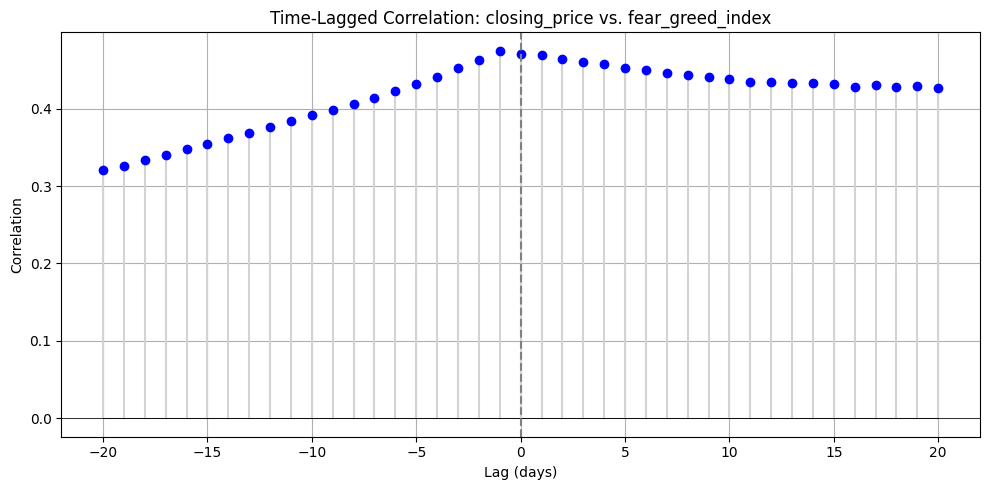

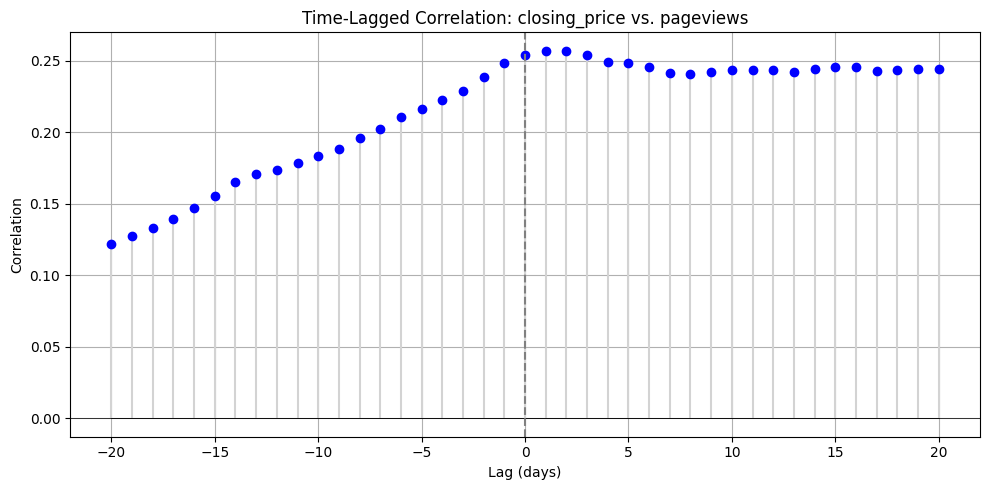

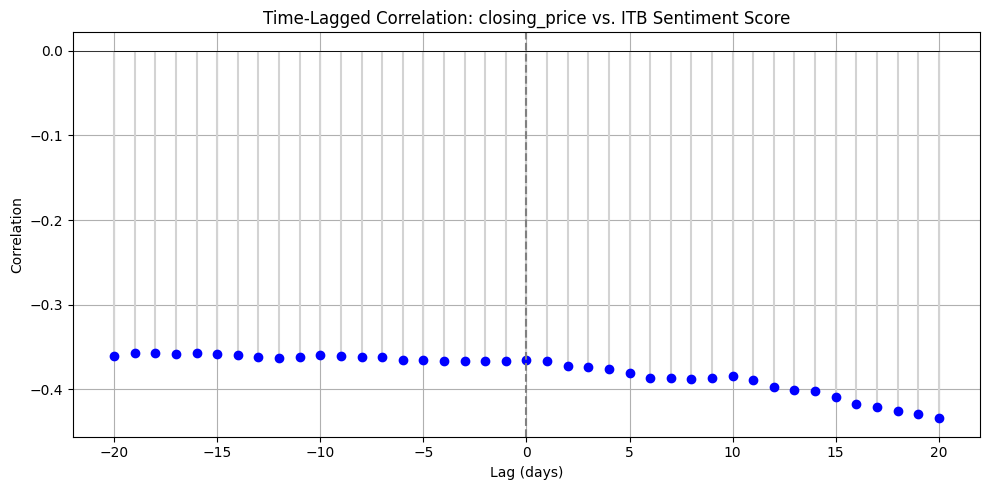

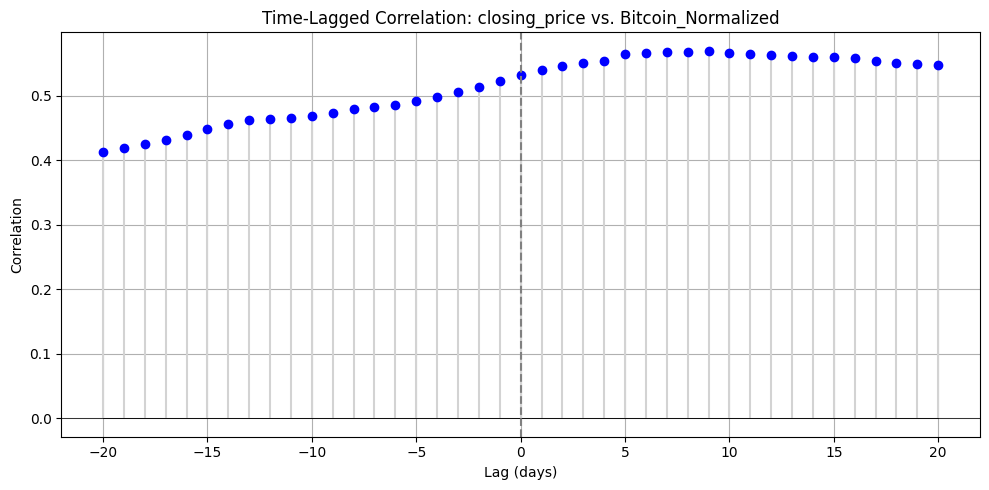

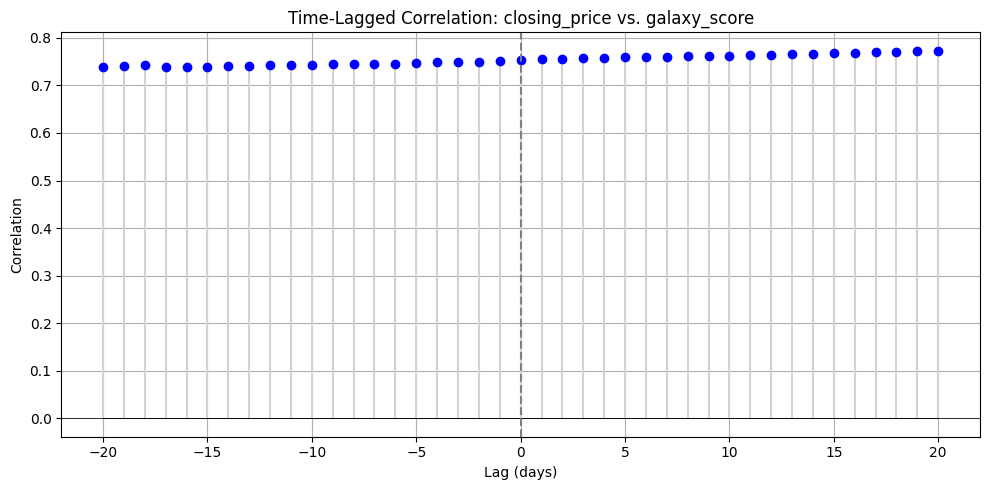

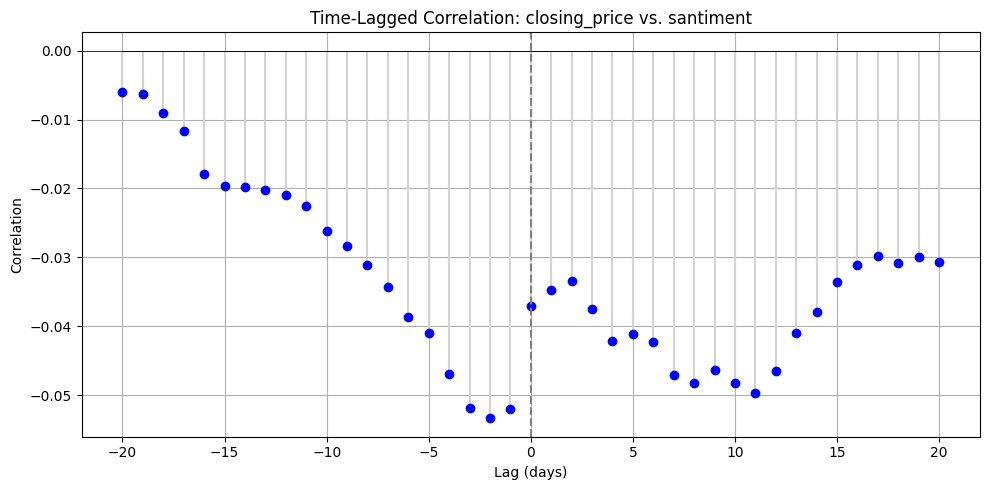

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def time_lagged_correlation_full(df, target_column, max_lag=20):
    """
    Computes and plots time-lagged Pearson correlations from -max_lag to +max_lag
    between the target column and all other columns in the DataFrame.
    """
    target = df[target_column]
    target = (target - target.mean()) / target.std()  # Normalize target

    for col in df.columns:
        if col == target_column:
            continue
        series = (df[col] - df[col].mean()) / df[col].std()  # Normalize

        lags = range(-max_lag, max_lag + 1)
        correlations = []

        for lag in lags:
            if lag < 0:
                corr = target.shift(-lag).corr(series)
            else:
                corr = target.corr(series.shift(lag))
            correlations.append(corr)

        # Plot
        plt.figure(figsize=(10, 5))
        # Check if using Matplotlib version 3.3 or higher
        # If yes, use use_line_collection=True for better performance
        # If not, omit use_line_collection argument for compatibility

        # Remove 'use_line_collection=True'
        markerline, stemlines, baseline = plt.stem(lags, correlations)
        plt.setp(markerline, color='blue', marker='o')  # Customize marker color and style
        plt.setp(stemlines, color='lightgray', linestyle='-') # Customize stemlines color and style
        plt.setp(baseline, color='black', linewidth=0.5)      # Customize baseline color and width

        plt.axhline(0, color='black', linewidth=0.5)
        plt.axvline(0, color='gray', linestyle='--')
        plt.title(f"Time-Lagged Correlation: {target_column} vs. {col}")
        plt.xlabel("Lag (days)")
        plt.ylabel("Correlation")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Call with your matrix
time_lagged_correlation_full(matrix2_no_date, 'closing_price', max_lag=20)

## Dynamic Time Warping (DTW)

In [ ]:
pip install dtaidistance

In [ ]:
matrix2_filtered = matrix2_no_date

for col in matrix2_filtered.columns[0:]:
    matrix2_filtered[col] = (matrix2_filtered[col] - matrix2_filtered[col].min()) / (matrix2_filtered[col].max() - matrix2_filtered[col].min())

In [ ]:
matrix2_filtered.head()

,BCP,FGI,WVI,ITB,GTI,LCG,SAN
0,0.035418,0.610390,0.067517,0.316266,0.059030,0.040816,0.241038
1,0.024873,0.610390,0.085534,0.384990,0.086255,0.040816,1.000000
2,0.026455,0.545455,0.088045,0.297684,0.080854,0.040816,0.777721
3,0.039789,0.519481,0.102453,0.264089,0.086255,0.040816,0.707699
4,0.035903,0.558442,0.113985,0.407453,0.083554,0.040816,0.645196


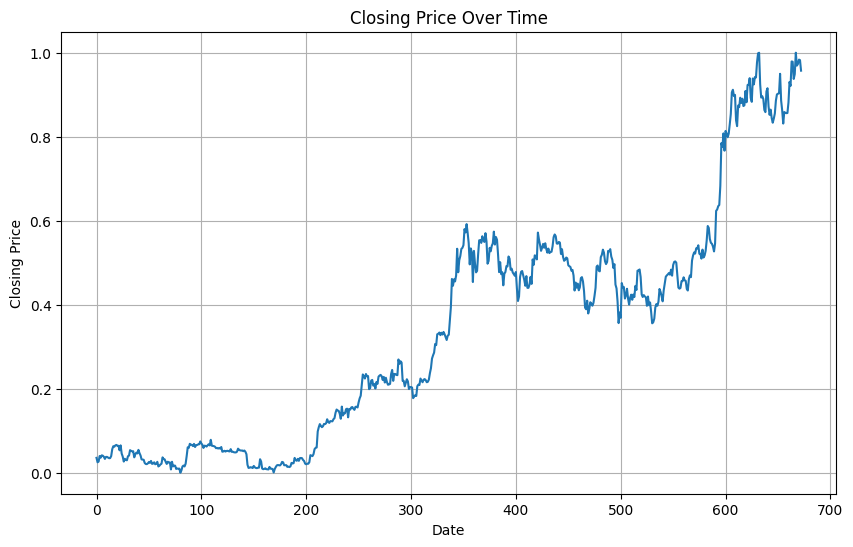

In [ ]:
# prompt: plot matrix2_filtered closing_price

plt.figure(figsize=(10, 6))
plt.plot(matrix2_filtered['BCP'])
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Closing Price Over Time')
plt.grid(True)
plt.show()

In [ ]:
# prompt: do the Dynamic Time Warping similarity with closing_price for all the colums in matrix2 except the date

from dtaidistance import dtw

# Assuming matrix2_filtered is your normalized DataFrame (from previous code)
# and you want to calculate DTW distances for 'closing_price' against other columns

for col in matrix2_filtered.columns[1:]:
    if col != 'closing_price':  # Skip comparing closing_price to itself
        distance = dtw.distance(matrix2_filtered['BCP'], matrix2_filtered[col])
        print(f"DTW Distance between BCP and {col}: {distance}")


DTW Distance between BCP and FGI: 6.354630696513098
DTW Distance between BCP and WVI: 5.739578229108886
DTW Distance between BCP and ITB: 5.248669885410851
DTW Distance between BCP and GTI: 5.709671385937093
DTW Distance between BCP and LCG: 3.1088185441958025
DTW Distance between BCP and SAN: 6.1808702571568555


In [ ]:
# prompt: discuss briefly this results: DTW Distance between BCP and FGI: 6.354630696513098
# DTW Distance between BCP and WVI: 5.739578229108886
# DTW Distance between BCP and ITB: 5.248669885410851
# DTW Distance between BCP and GTI: 5.709671385937093
# DTW Distance between BCP and LCG: 3.1088185441958025
# DTW Distance between BCP and SAN: 6.1808702571568555

The provided code analyzes the correlation and similarity between Bitcoin closing prices (BCP) and various other time series data. Let's break down the results you shared and their implications:

**DTW Distances:**

Dynamic Time Warping (DTW) measures the similarity between two time series, even if they are shifted in time or have different lengths.  Lower DTW distances indicate higher similarity.  Here's an interpretation of your results:

* **BCP vs. LCG:** The smallest DTW distance (3.11) suggests that LCG (likely another cryptocurrency or financial indicator) has the highest similarity to Bitcoin's closing prices.  Their patterns align relatively well.
* **BCP vs. ITB, GTI:**  These have moderate DTW distances (around 5.25 and 5.71), indicating a reasonable degree of similarity, though less than LCG.
* **BCP vs. WVI, SAN, FGI:** These show larger distances (between 5.74 and 6.35), implying less similarity in their time series patterns compared to the others.

**Key Considerations and Further Analysis:**

1. **Context of the Data:** Without knowing what FGI, WVI, ITB, GTI, LCG, and SAN represent, it's hard to draw definitive conclusions. Understanding their meaning is crucial. For example, are they other cryptocurrencies, market indices, trading volumes, or sentiment indicators?
2. **Significance Testing:**  The DTW distances alone do not tell us if these differences are statistically significant.  You'd need to perform statistical tests to determine if the differences between these distances are meaningful or simply due to random fluctuations.
3. **Visualization:** Plotting the time series of BCP against each of these indicators side-by-side would be very helpful.  Visual inspection can often confirm or refute the DTW distances.  Look for patterns, trends, and any potential time lags between the series.
4. **Normalization:** You've normalized the data, which is good practice for DTW. Ensure that the normalization is appropriate for your data and doesn't obscure underlying patterns.
5. **Correlation Analysis Results:** The code also calculates Pearson, Spearman, Kendall, and Distance correlations. These results provide complementary insights into the linear and non-linear relationships between BCP and the other indicators.  Combine the correlation results with the DTW distances for a holistic understanding.  Look for any inconsistencies; for example, a high correlation but a large DTW distance could suggest a non-linear relationship.
6. **Time Lagged Correlation:**  Time lagged correlations help identify potential lead-lag relationships.  A significant positive correlation at a positive lag implies that one indicator tends to change *before* BCP, and vice versa. Explore the lag periods highlighted in the analysis for more insight.
7. **Feature Engineering:** Based on the initial analysis (correlation, DTW, time lagged correlations), you may be able to create more informative features. For instance, if you find a strong lead-lag relationship, you could incorporate a time-lagged version of the leading variable into a predictive model.

**In summary:**  The DTW distances suggest varying degrees of similarity between Bitcoin's price and other time series.  However, a deeper analysis combining the other correlation metrics, visualizations, statistical tests, and domain expertise is needed to draw meaningful conclusions about potential predictive relationships or identify shared characteristics among the indicators.


### Altro metodo

In [ ]:
pip install dtw

  Preparing metadata (setup.py) ... done
  Created wheel for dtw: filename=dtw-1.4.0-py3-none-any.whl size=5301 sha256=158bf45c46cc83d077c0838e9eadc560c241149ae8290e625162782c4ab78ca9
  Stored in directory: /root/.cache/pip/wheels/2c/16/01/ffea89493a0fcd29934418eb0bf10161470acf8d5647bab656
Successfully built dtw


DTW distance: 143.9889


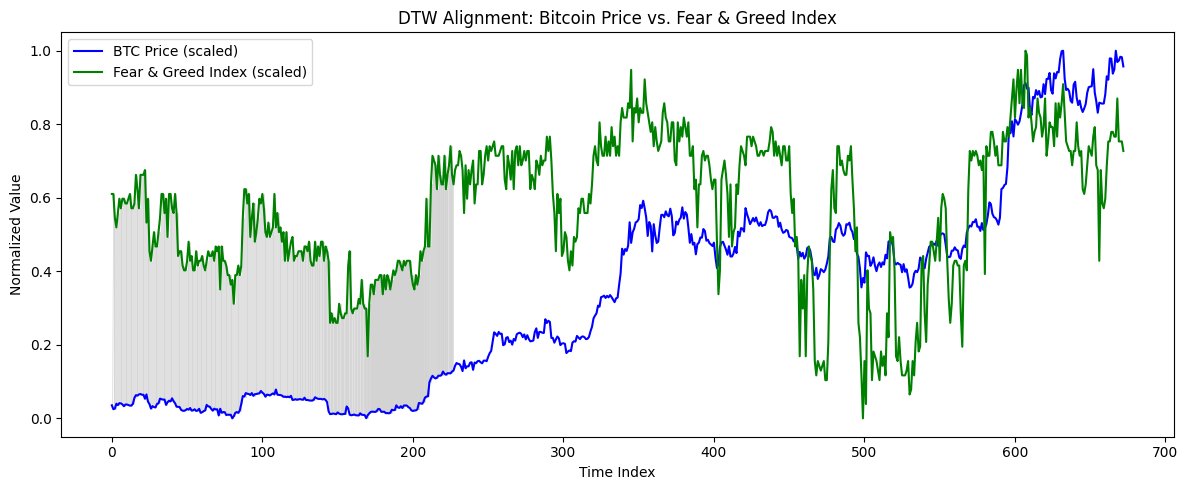

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from dtw import dtw
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import euclidean

# Extract the series
btc = matrix2['closing_price'].values
fgi = matrix2['fear_greed_index'].values

# Normalize the series
scaler = MinMaxScaler()
btc_scaled = scaler.fit_transform(btc.reshape(-1, 1)).flatten()
fgi_scaled = scaler.fit_transform(fgi.reshape(-1, 1)).flatten()

# Apply DTW
# The dtw function returns a tuple: (distance, cost_matrix, acc_cost_matrix, path)
# We only need the distance, so we unpack it using [0]

# The dist parameter should be a callable that takes two 1D arrays as input
# and returns a scalar distance value.
# Here we wrap the euclidean function to ensure it receives 1D arrays.
def dist_func(x, y):
    return euclidean(x.reshape(-1), y.reshape(-1))

# Get the distance from the returned tuple
distance, _, _, _ = dtw(btc_scaled, fgi_scaled, dist=dist_func)

# Print DTW distance
print(f"DTW distance: {distance:.4f}")

# Plot alignment
plt.figure(figsize=(12, 5))

# Iterate through the alignment path using index1 and index2
for i, j in zip(alignment[2][:,0], alignment[2][:,1]): #Use index1 and index2 for alignment
    plt.plot([i, j], [btc_scaled[int(i)], fgi_scaled[int(j)]], color='lightgray', linewidth=0.5)

plt.plot(btc_scaled, label='BTC Price (scaled)', color='blue')
plt.plot(fgi_scaled, label='Fear & Greed Index (scaled)', color='green')
plt.title("DTW Alignment: Bitcoin Price vs. Fear & Greed Index")
plt.xlabel("Time Index")
plt.ylabel("Normalized Value")
plt.legend()
plt.tight_layout()
plt.show()

### Code Example: Rolling DTW

In [ ]:
import numpy as np
import pandas as pd
from dtw import dtw
from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt

# Parameters
window_size = 30
step_size = 1

# Containers
rolling_distances = []
rolling_dates = []

# Series
btc = matrix2['closing_price'].values
fgi = matrix2['fear_greed_index'].values
dates = matrix2.index

# Loop over rolling windows
for start in range(0, len(btc) - window_size + 1, step_size):
    end = start + window_size
    btc_window = btc[start:end]
    fgi_window = fgi[start:end]

    # Normalize
    scaler = MinMaxScaler()
    btc_scaled = scaler.fit_transform(btc_window.reshape(-1, 1)).flatten()
    fgi_scaled = scaler.fit_transform(fgi_window.reshape(-1, 1)).flatten()

    # Compute DTW
    alignment = dtw(btc_scaled, fgi_scaled, dist=lambda x, y: euclidean(x.reshape(-1), y.reshape(-1)))
    rolling_distances.append(alignment[0])  # Access the distance using index 0
    rolling_dates.append(dates[end - 1])  # use end of window as the date

Plot Rolling DTW Distances

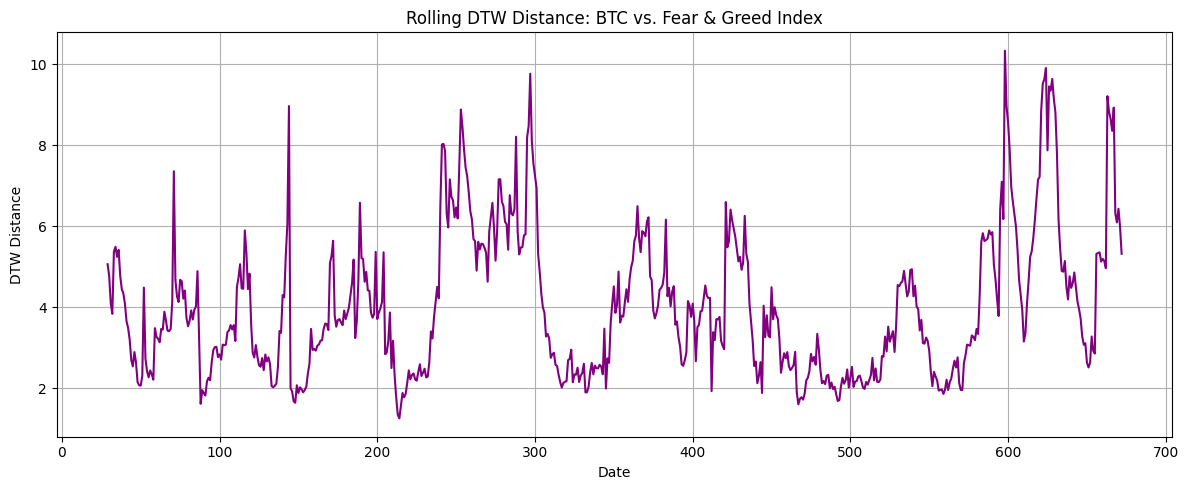

In [ ]:
# Convert to DataFrame
rolling_df = pd.DataFrame({
    'date': rolling_dates,
    'dtw_distance': rolling_distances
})

# Plot
plt.figure(figsize=(12, 5))
plt.plot(rolling_df['date'], rolling_df['dtw_distance'], color='purple')
plt.title("Rolling DTW Distance: BTC vs. Fear & Greed Index")
plt.xlabel("Date")
plt.ylabel("DTW Distance")
plt.grid(True)
plt.tight_layout()
plt.show()

# Step 3: Econometric framework

In [ ]:
import pandas as pd
from google.colab import files

matrix2 = pd.read_csv('matrix1.csv')
matrix2.head()

,date,closing_price,fear_greed_index,pageviews,ITB Sentiment Score,Bitcoin_Normalized,galaxy_score
0,2021-06-18,35787.246094,25.0,18044,-0.638211,26.707843,61
1,2021-06-19,35615.871094,23.0,15534,-0.592391,24.279857,71
2,2021-06-20,35698.296875,21.0,15696,-0.613527,27.921836,58
3,2021-06-21,31676.693359,23.0,19225,-0.671053,21.566434,67
4,2021-06-22,32505.660156,10.0,21093,-0.738791,29.653846,72


In [ ]:
matrix2.describe()

,closing_price,fear_greed_index,pageviews,ITB Sentiment Score,Bitcoin_Normalized,galaxy_score
count,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000
mean,43148.441105,48.134872,13410.456621,-0.443808,15.598462,57.017504
std,21023.570489,21.251884,7264.047519,0.241174,6.520249,12.966434
min,15787.284180,6.000000,4785.000000,-0.896174,7.018147,40.000000
25%,26678.235840,27.000000,8440.250000,-0.594224,11.011242,44.000000
50%,39453.376953,50.000000,10781.500000,-0.484486,13.713876,58.000000
75%,59117.727539,69.000000,16196.500000,-0.356822,18.623914,70.000000
max,106146.265625,94.000000,83841.000000,0.748627,71.888112,89.000000


## ADF tests

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [ ]:
for col in matrix2.columns:
  if col != 'date':
    print(f"Performing ADF test on column: {col}")
    adf_test(matrix2[col])
    print("-" * 30) # Separator between test results

    # Interpretation of ADF test results
    result = adfuller(matrix2[col])
    p_value = result[1]
    if p_value < 0.05:
      print(f"The time series in column '{col}' is likely stationary.")
    else:
      print(f"The time series in column '{col}' is likely non-stationary.")
    print("-" * 30)


NameError: name 'matrix2' is not defined

## Granger Causality Test

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Loop through all columns except 'date' and 'closing_price'
for col in matrix2.columns:
  if col not in ['date', 'BCP']:
    print(f"Granger Causality Test: closing_price vs. {col}")
    try:
      # Perform the Granger causality test
      test_result = grangercausalitytests(matrix2[['BCP', col]], maxlag=5)

      # Interpret the results for each lag
      for lag, result in test_result.items():
          p_value = result[0]['ssr_ftest'][1]
          print(f"  Lag {lag}:")
          print(f"    P-value: {p_value:.4f}")
          if p_value < 0.05:
              print("    Granger causality exists at this lag (reject H0)")
          else:
              print("    No Granger causality at this lag (fail to reject H0)")
          print("-" * 20)
    except Exception as e:
      print(f"Error performing Granger causality test for {col}: {e}")
    print("-" * 40) # Separator between different columns

Granger Causality Test: closing_price vs. FGI

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0985  , p=0.7538  , df_denom=669, df_num=1
ssr based chi2 test:   chi2=0.0989  , p=0.7531  , df=1
likelihood ratio test: chi2=0.0989  , p=0.7532  , df=1
parameter F test:         F=0.0985  , p=0.7538  , df_denom=669, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.8478  , p=0.1584  , df_denom=666, df_num=2
ssr based chi2 test:   chi2=3.7234  , p=0.1554  , df=2
likelihood ratio test: chi2=3.7131  , p=0.1562  , df=2
parameter F test:         F=1.8478  , p=0.1584  , df_denom=666, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.4474  , p=0.2279  , df_denom=663, df_num=3
ssr based chi2 test:   chi2=4.3879  , p=0.2225  , df=3
likelihood ratio test: chi2=4.3736  , p=0.2238  , df=3
parameter F test:         F=1.4474  , p=0.2279  , df_denom=663, df_num=3

Granger Causality
number of lags (no zero) 4
ss

## Cointegration test

In [ ]:
from statsmodels.tsa.stattools import coint

In [ ]:
for col in matrix2.columns:
    if col not in ['date', 'BCP']:
        print(f"Cointegration Test: BCP vs. {col}")
        try:
            # Perform the cointegration test
            score, pvalue, crit = coint(matrix2['BCP'], matrix2[col])

            print(f"  t-statistic: {score:.4f}")
            print(f"  p-value: {pvalue:.4f}")
            print(f"  Critical values: {crit}")

            # Interpret the results
            if pvalue < 0.05:
                print("  Series are cointegrated (reject H0)")
            else:
                print("  Series are not cointegrated (fail to reject H0)")
        except Exception as e:
            print(f"Error performing cointegration test for {col}: {e}")
        print("-" * 40)  # Separator between different columns

Cointegration Test: BCP vs. FGI
  t-statistic: -0.5401
  p-value: 0.9614
  Critical values: [-3.91281171 -3.34523752 -3.05076733]
  Series are not cointegrated (fail to reject H0)
----------------------------------------
Cointegration Test: BCP vs. WVI
  t-statistic: 0.0508
  p-value: 0.9870
  Critical values: [-3.91281171 -3.34523752 -3.05076733]
  Series are not cointegrated (fail to reject H0)
----------------------------------------
Cointegration Test: BCP vs. ITB
  t-statistic: 0.1005
  p-value: 0.9880
  Critical values: [-3.91281171 -3.34523752 -3.05076733]
  Series are not cointegrated (fail to reject H0)
----------------------------------------
Cointegration Test: BCP vs. GTI
  t-statistic: -0.6803
  p-value: 0.9487
  Critical values: [-3.91281171 -3.34523752 -3.05076733]
  Series are not cointegrated (fail to reject H0)
----------------------------------------
Cointegration Test: BCP vs. LCG
  t-statistic: -1.9249
  p-value: 0.5673
  Critical values: [-3.91281171 -3.34523752 -

## Split Train-Test

In [ ]:
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(matrix2, test_size=0.2, shuffle=False) # Use train_test_split for splitting
print(train_data.shape)
test_data.shape

(538, 8)


(135, 8)

## Benchmark model: autoregressive model

In [ ]:
# Fit the autoregressive model to the training data
model = AutoReg(train_data['closing_price'], lags=1)  # Adjust lags as needed
model_fit = model.fit()

# Make predictions on the test data
predictions = model_fit.predict(start=len(train_data), end=len(matrix2)-1)

In [ ]:
import numpy as np # linear algebra
# Evaluate the model
# rmse = mean_squared_error(test_data['closing_price'], predictions, squared=False) # Original line causing the error
rmse = np.sqrt(mean_squared_error(test_data['closing_price'], predictions)) # Calculate RMSE manually
print(f"RMSE: {rmse}")

RMSE: 27883.469504585093


In [ ]:
# prompt: calculate the mape

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test_data['closing_price'], predictions)
print(f"MAPE: {mape}")


MAPE: 0.2447416738296745


After the benchmark with AR we have to test ARDL and after GRU

## ARDL Modelling and FORECASTING

### Fear and Greed Index

In [ ]:
# prompt: now lets train an ardl model on train_data to forecast closing_prices using fear_greed_index as exogenous variable
from statsmodels.tsa.ardl import ardl_select_order
from statsmodels.tsa.ardl import ARDL
from sklearn.metrics import mean_squared_error

# Assuming 'train_data' is your DataFrame and it has 'closing_price' and 'fear_greed_index' columns
# and you have already performed necessary data preprocessing and stationarity checks.


# Define the exogenous variable
exog = train_data[["fear_greed_index"]]

# Determine optimal ARDL order (you might need to adjust the maxlags)
sel_res = ardl_select_order(train_data.closing_price, 8, exog.loc[train_data.index], 8, ic="aic", trend="c", causal=True)

print(f"The optimal order is: {sel_res.model.ardl_order}")

The optimal order is: (2, 2)


In [ ]:
# Fit ARDL model on training data
model = ARDL(train_data.closing_price, sel_res.model.ardl_order[0], exog.loc[train_data.index], sel_res.model.ardl_order[1])
ardl_model = model.fit()
print(ardl_model.summary())

                              ARDL Model Results                              
Dep. Variable:          closing_price   No. Observations:                  538
Model:                     ARDL(2, 2)   Log Likelihood               -4598.094
Method:               Conditional MLE   S.D. of innovations           1286.390
Date:                Thu, 10 Apr 2025   AIC                           9210.188
Time:                        21:55:54   BIC                           9240.177
Sample:                             2   HQIC                          9221.920
                                  538                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 299.9390    250.343      1.198      0.231    -191.847     791.725
closing_price.L1        0.8547      0.058     14.797      0.000       0.741       0.968
closing_price.L2

In [ ]:
# Make predictions using the fitted ARDL model
# Assuming 'data' is the original DataFrame you split into train_data and test_data

#Original: predictions = ardl_model.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, exog=test_data[['fear_greed_index']]) # Pass exog as a DataFrame

# Pass test_data[['fear_greed_index']] as exog_oos to predict out-of-sample
predictions = ardl_model.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, exog_oos=test_data[['fear_greed_index']])

In [ ]:
# prompt: calculate the rmse of the predictions on the test:_data

rmse = np.sqrt(mean_squared_error(test_data['closing_price'], predictions))
print(f"RMSE: {rmse}")

RMSE: 26373.028990951007


In [ ]:
# prompt: try another error measure like mape

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test_data['closing_price'], predictions)
print(f"MAPE: {mape}")


MAPE: 0.2249255019045726


### NARDL

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.ardl import ardl_select_order, ARDL
from sklearn.metrics import mean_squared_error

# 1. Decompose fear_greed_index into positive and negative cumulative changes
train_data['fg_diff'] = train_data['fear_greed_index'].diff()

# Partial sums
train_data['fg_pos'] = train_data['fg_diff'].clip(lower=0).fillna(0).cumsum()
train_data['fg_neg'] = train_data['fg_diff'].clip(upper=0).fillna(0).cumsum()

# Fill any remaining NaNs if needed
train_data = train_data.fillna(method='bfill')

# Define the new exogenous variables
exog_nl = train_data[['fg_pos', 'fg_neg']]

# 2. Select optimal lag order
sel_res = ardl_select_order(train_data['closing_price'], maxlag=8,
                            exog=exog_nl.loc[train_data.index], maxorder=8,
                            ic='aic', trend='c', causal=True)

print(f"The optimal order is: {sel_res.model.ardl_order}")

# 3. Fit the NARDL model
model = ARDL(train_data['closing_price'],
             lags=sel_res.model.ardl_order[0],
             exog=exog_nl.loc[train_data.index],
             exog_lags=sel_res.model.ardl_order[1])
nardl_model = model.fit()
print(nardl_model.summary())

# 4. Prepare test data (with same decomposition)
test_data['fg_diff'] = test_data['fear_greed_index'].diff()
test_data['fg_pos'] = test_data['fg_diff'].clip(lower=0).fillna(0).cumsum()
test_data['fg_neg'] = test_data['fg_diff'].clip(upper=0).fillna(0).cumsum()

# Align index and fill any missing values
test_data = test_data.fillna(method='bfill')

# 5. Make out-of-sample predictions
exog_test = test_data[['fg_pos', 'fg_neg']]
predictions = nardl_model.predict(start=len(train_data),
                                  end=len(train_data) + len(test_data) - 1,
                                  exog_oos=exog_test)

# 6. Evaluate RMSE
rmse = np.sqrt(mean_squared_error(test_data['closing_price'], predictions))
print(f"NARDL RMSE: {rmse}")

<ipython-input-19-e5a54d87ce26>:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_data = train_data.fillna(method='bfill')


The optimal order is: (2, 3)


TypeError: ARDL.__init__() got an unexpected keyword argument 'exog_lags'

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.ardl import ardl_select_order, ARDL
from sklearn.metrics import mean_squared_error

# 1. Decompose fear_greed_index into positive and negative cumulative changes
train_data['fg_diff'] = train_data['fear_greed_index'].diff()

# Partial sums
train_data['fg_pos'] = train_data['fg_diff'].clip(lower=0).fillna(0).cumsum()
train_data['fg_neg'] = train_data['fg_diff'].clip(upper=0).fillna(0).cumsum()

# Fill any remaining NaNs if needed
train_data = train_data.fillna(method='bfill')

# Define the new exogenous variables
exog_nl = train_data[['fg_pos', 'fg_neg']]

# 2. Select optimal lag order
sel_res = ardl_select_order(train_data['closing_price'], maxlag=8,
                            exog=exog_nl.loc[train_data.index], maxorder=8,
                            ic='aic', trend='c', causal=True)

print(f"The optimal order is: {sel_res.model.ardl_order}")

# 3. Fit the NARDL model
# Remove 'exog_lags' and use the standard ARDL model with transformed exogenous variables
model = ARDL(train_data['closing_price'],
             lags=sel_res.model.ardl_order[0],
             exog=exog_nl.loc[train_data.index])  # Remove exog_lags
nardl_model = model.fit()
print(nardl_model.summary())

# 4. Prepare test data (with same decomposition)
test_data['fg_diff'] = test_data['fear_greed_index'].diff()
test_data['fg_pos'] = test_data['fg_diff'].clip(lower=0).fillna(0).cumsum()
test_data['fg_neg'] = test_data['fg_diff'].clip(upper=0).fillna(0).cumsum()

# Align index and fill any missing values
test_data = test_data.fillna(method='bfill')

# 5. Make out-of-sample predictions
exog_test = test_data[['fg_pos', 'fg_neg']]
predictions = nardl_model.predict(start=len(train_data),
                                  end=len(train_data) + len(test_data) - 1,
                                  exog_oos=exog_test)

# 6. Evaluate RMSE
rmse = np.sqrt(mean_squared_error(test_data['closing_price'], predictions))
print(f"NARDL RMSE: {rmse}")

<ipython-input-20-17de8bd0b3e1>:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_data = train_data.fillna(method='bfill')


The optimal order is: (2, 3)
                              ARDL Model Results                              
Dep. Variable:          closing_price   No. Observations:                  538
Model:                  ARDL(2, 0, 0)   Log Likelihood               -4599.824
Method:               Conditional MLE   S.D. of innovations           1290.548
Date:                Thu, 10 Apr 2025   AIC                           9211.647
Time:                        21:59:30   BIC                           9237.352
Sample:                             2   HQIC                          9221.704
                                  538                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const              612.4335    297.175      2.061      0.040      28.650    1196.217
closing_price.L1     0.8638      0.047     18.514      0.000       0.772       0.955

<ipython-input-20-17de8bd0b3e1>:40: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_data = test_data.fillna(method='bfill')


Da sistemare...................

### Lunar Crush

In [ ]:
# prompt: now lets train an ardl model on train_data to forecast closing_prices using fear_greed_index as exogenous variable
from statsmodels.tsa.ardl import ardl_select_order
from statsmodels.tsa.ardl import ARDL
from sklearn.metrics import mean_squared_error

# Assuming 'train_data' is your DataFrame and it has 'closing_price' and 'fear_greed_index' columns
# and you have already performed necessary data preprocessing and stationarity checks.


# Define the exogenous variable
exog = train_data[["galaxy_score"]]

# Determine optimal ARDL order (you might need to adjust the maxlags)
sel_res = ardl_select_order(train_data.closing_price, 8, exog.loc[train_data.index], 8, ic="aic", trend="c", causal=True)
print(f"The optimal order is: {sel_res.model.ardl_order}")

# Fit ARDL model on training data
model = ARDL(train_data.closing_price, sel_res.model.ardl_order[0], exog.loc[train_data.index], sel_res.model.ardl_order[1])
ardl_model = model.fit()
print(ardl_model.summary())

The optimal order is: (2, 3)
                              ARDL Model Results                              
Dep. Variable:          closing_price   No. Observations:                  538
Model:                     ARDL(2, 3)   Log Likelihood               -4595.435
Method:               Conditional MLE   S.D. of innovations           1280.024
Date:                Mon, 10 Mar 2025   AIC                           9206.870
Time:                        18:22:40   BIC                           9241.143
Sample:                             3   HQIC                          9220.278
                                  538                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const             -157.4986    228.194     -0.690      0.490    -605.775     290.778
closing_price.L1     0.8892      0.043     20.560      0.000       0.804       0.974

In [ ]:
# Make predictions using the fitted ARDL model
# Assuming 'data' is the original DataFrame you split into train_data and test_data

#Original: predictions = ardl_model.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, exog=test_data[['fear_greed_index']]) # Pass exog as a DataFrame

# Pass test_data[['fear_greed_index']] as exog_oos to predict out-of-sample
predictions = ardl_model.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, exog_oos=test_data[['galaxy_score']])

In [ ]:
# prompt: calculate the rmse of the predictions on the test:_data

rmse = np.sqrt(mean_squared_error(test_data['closing_price'], predictions))
print(f"RMSE: {rmse}")

RMSE: 23706.646433691643


In [ ]:
# prompt: try another error measure like mape

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test_data['closing_price'], predictions)
print(f"MAPE: {mape}")


MAPE: 0.20315984736696052


### *Google Trends Index*

In [ ]:
# prompt: now lets train an ardl model on train_data to forecast closing_prices using fear_greed_index as exogenous variable
from statsmodels.tsa.ardl import ardl_select_order
from statsmodels.tsa.ardl import ARDL
from sklearn.metrics import mean_squared_error

# Assuming 'train_data' is your DataFrame and it has 'closing_price' and 'fear_greed_index' columns
# and you have already performed necessary data preprocessing and stationarity checks.


# Define the exogenous variable
exog = train_data[["Bitcoin_Normalized"]]

# Determine optimal ARDL order (you might need to adjust the maxlags)
sel_res = ardl_select_order(train_data.closing_price, 8, exog.loc[train_data.index], 8, ic="aic", trend="c", causal=True)
print(f"The optimal order is: {sel_res.model.ardl_order}")

# Fit ARDL model on training data
model = ARDL(train_data.closing_price, sel_res.model.ardl_order[0], exog.loc[train_data.index], sel_res.model.ardl_order[1])
ardl_model = model.fit()
print(ardl_model.summary())

The optimal order is: (2, 5)
                              ARDL Model Results                              
Dep. Variable:          closing_price   No. Observations:                  538
Model:                     ARDL(2, 5)   Log Likelihood               -4590.629
Method:               Conditional MLE   S.D. of innovations           1268.598
Date:                Mon, 10 Mar 2025   AIC                           9201.258
Time:                        18:31:01   BIC                           9244.099
Sample:                             5   HQIC                          9218.019
                                  538                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  -127.1475    198.997     -0.639      0.523    -518.072     263.777
closing_price.L1          0.8749      0.043     20.168      0.000    

In [ ]:
# Make predictions using the fitted ARDL model
# Assuming 'data' is the original DataFrame you split into train_data and test_data

#Original: predictions = ardl_model.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, exog=test_data[['fear_greed_index']]) # Pass exog as a DataFrame

# Pass test_data[['fear_greed_index']] as exog_oos to predict out-of-sample
predictions = ardl_model.predict(start=len(train_data), end=len(train_data) + len(test_data) - 1, exog_oos=test_data[['Bitcoin_Normalized']])

In [ ]:
# prompt: calculate the rmse of the predictions on the test:_data

rmse = np.sqrt(mean_squared_error(test_data['closing_price'], predictions))
print(f"RMSE: {rmse}")

RMSE: 20752.57232357195


In [ ]:
# prompt: try another error measure like mape

from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test_data['closing_price'], predictions)
print(f"MAPE: {mape}")


MAPE: 0.20944691940055554


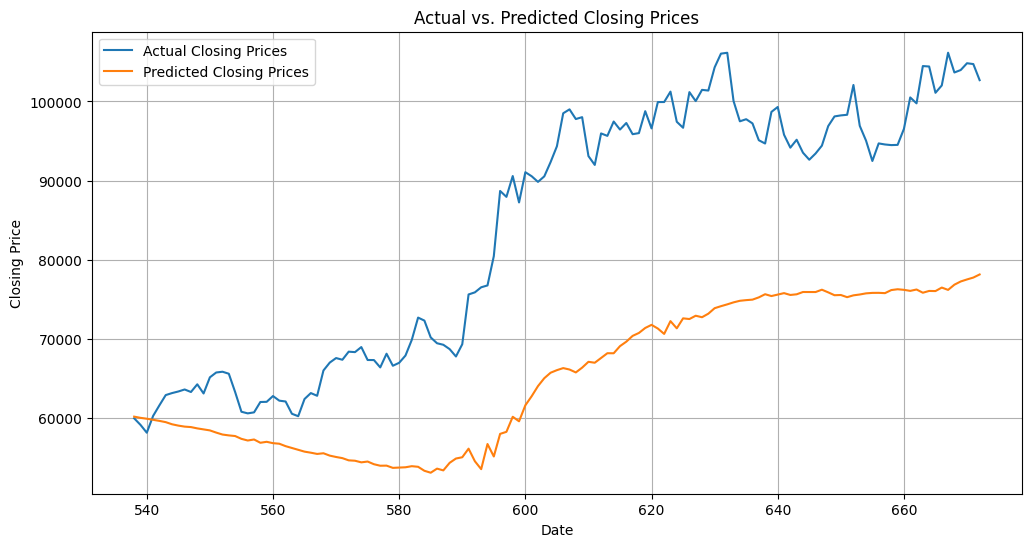

In [ ]:
# prompt: plot the predictions and the actual closing prices

plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['closing_price'], label='Actual Closing Prices')
plt.plot(test_data.index, predictions, label='Predicted Closing Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.title('Actual vs. Predicted Closing Prices')
plt.legend()
plt.grid(True)
plt.show()


## Subsample Bootstrap Rolling Window Granger Causality Method

In [ ]:
# prompt: create a dataset with closing prices and fear and greed index from matrix2

# Assuming 'matrix2' DataFrame is already loaded and contains 'closing_price' and 'fear_greed_index'
# Create a new DataFrame with the desired columns
data = matrix2[['date', 'closing_price', 'fear_greed_index']]
# Display the first few rows of the dataset
print(data.head())


        date  closing_price  fear_greed_index
0 2023-03-27   27994.330078              64.0
1 2023-03-28   27139.888672              64.0
2 2023-03-29   27268.130859              59.0
3 2023-03-30   28348.441406              57.0
4 2023-03-31   28033.562500              60.0


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

def rolling_window_granger_causality(data, max_lag, window_size, bootstrap_reps=50, significance_level=0.05):
    """
    Performs a subsample bootstrap rolling window Granger causality test.

    Parameters:
    - data: Pandas DataFrame with time series (columns are variables).
    - max_lag: Maximum number of lags for the Granger causality test.
    - window_size: Size of the rolling window.
    - bootstrap_reps: Number of bootstrap resamples.
    - significance_level: Significance threshold for causality.

    Returns:
    - results: DataFrame with rolling window p-values.
    """

    num_windows = len(data) - window_size + 1
    p_values = []

    for start in range(num_windows):
        # Define rolling window
        window_data = data.iloc[start : start + window_size]

        # Fit VAR model
        model = VAR(window_data)
        result = model.fit(maxlags=max_lag)

        # Perform standard Granger causality test
        test_result = grangercausalitytests(window_data, max_lag, verbose=False)
        p_value = test_result[max_lag][0]['ssr_ftest'][1]  # Extract p-value

        # Bootstrap resampling
        bootstrap_p_values = []
        for _ in range(bootstrap_reps):
            # Resample residuals
            boot_residuals = result.resid.sample(frac=1, replace=True).reset_index(drop=True)
            boot_data = window_data.copy()
            boot_data.iloc[max_lag:] += boot_residuals.values

            # Fit VAR on bootstrapped data
            boot_result = VAR(boot_data).fit(maxlags=max_lag)
            boot_test = grangercausalitytests(boot_data, max_lag, verbose=False)
            boot_p_value = boot_test[max_lag][0]['ssr_ftest'][1]
            bootstrap_p_values.append(boot_p_value)

        # Compute bootstrap confidence interval
        lower_bound = np.percentile(bootstrap_p_values, significance_level * 100 / 2)
        upper_bound = np.percentile(bootstrap_p_values, (1 - significance_level / 2) * 100)

        # Store results
        p_values.append((start, p_value, lower_bound, upper_bound))

    return pd.DataFrame(p_values, columns=["Start_Index", "P_Value", "Lower_CI", "Upper_CI"])

# Example usage
# Load time series data (Replace with actual financial data)
np.random.seed(42)
data = pd.DataFrame({
    "X": np.random.randn(200),
    "Y": np.random.randn(200)
})

# Apply rolling Granger causality
results = rolling_window_granger_causality(data, max_lag=2, window_size=50)
print(results)

Output streaming troncato alle ultime 5000 righe.
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is

     Start_Index   P_Value  Lower_CI  Upper_CI
0              0  0.447421  0.054650  0.942777
1              1  0.440950  0.028525  0.956867
2              2  0.388783  0.056457  0.943265
3              3  0.364063  0.036971  0.943494
4              4  0.532137  0.109837  0.985656
..           ...       ...       ...       ...
146          146  0.168306  0.011194  0.939943
147          147  0.113999  0.029362  0.965364
148          148  0.133329  0.013796  0.975866
149          149  0.179014  0.021778  0.915149
150          150  0.141506  0.033300  0.962574

[151 rows x 4 columns]


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


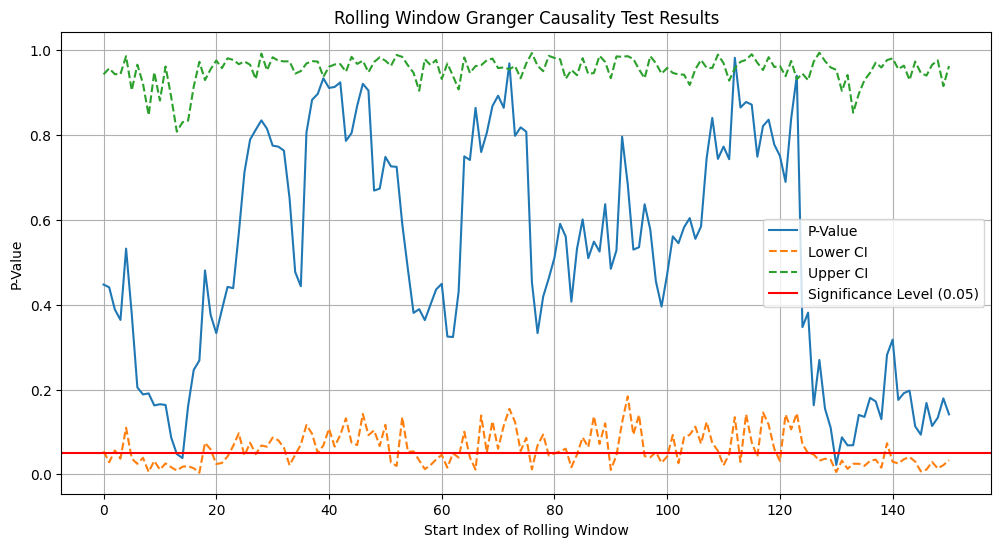

In [ ]:
# prompt: visualize with some graphs the results of the tests

import matplotlib.pyplot as plt

# Assuming 'results' DataFrame from rolling_window_granger_causality is available

plt.figure(figsize=(12, 6))
plt.plot(results["Start_Index"], results["P_Value"], label="P-Value")
plt.plot(results["Start_Index"], results["Lower_CI"], label="Lower CI", linestyle="--")
plt.plot(results["Start_Index"], results["Upper_CI"], label="Upper CI", linestyle="--")
plt.axhline(y=0.05, color='r', linestyle='-', label='Significance Level (0.05)')  # Add significance level line
plt.xlabel("Start Index of Rolling Window")
plt.ylabel("P-Value")
plt.title("Rolling Window Granger Causality Test Results")
plt.legend()
plt.grid(True)
plt.show()


# Step 4: Machine Learning Forecasting

In [ ]:
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Anche qui forse conviene fare benchmark con solo closing pricess...

In [ ]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(matrix2, test_size=0.2, shuffle=False) # Use train_test_split for splitting
print(train_data.shape)
test_data.shape

(538, 8)


(135, 8)

In [ ]:
# prompt: lets create a gru bevchmark model thet predict using only the cxlosing_price

import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Assuming 'matrix2' DataFrame is already loaded and preprocessed
# ... (Your existing code to load and preprocess data)

# Prepare data for GRU
data = matrix2[['closing_price']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Split into train and test
train_size = int(len(data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Create sequences for GRU
def create_sequences(data, seq_length):
  xs = []
  ys = []
  for i in range(len(data)-seq_length-1):
    x = data[i:(i+seq_length)]
    y = data[i+seq_length]
    xs.append(x)
    ys.append(y)
  return np.array(xs), np.array(ys)

seq_length = 20  # Adjust sequence length as needed
x_train, y_train = create_sequences(train_data, seq_length)
x_test, y_test = create_sequences(test_data, seq_length)

# Build the GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(GRU(units=50))
model.add(Dense(units=1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, epochs=50, batch_size=32) # Adjust epochs and batch_size as needed

# Make predictions
predicted_price = model.predict(x_test)
predicted_price = scaler.inverse_transform(predicted_price)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(scaler.inverse_transform(y_test), predicted_price))
print(f'RMSE: {rmse}')

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0570
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0036
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0013
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 5.0807e-04
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 5.9561e-04
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.7320e-04
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.0323e-04
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 5.2722e-04
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 5.0690e-04
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 4.4226e-04
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 4.7208e-04
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.9223e-04
Epoch 13/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3.8247e-04
Epoch 14/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 3.5449e-04
Epoch 15/50
17/17 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
mape = mean_absolute_percentage_error(scaler.inverse_transform(y_test), predicted_price)
print(f"MAPE: {mape}")

MAPE: 0.02788000139225589


Stesso RMSE di prima...

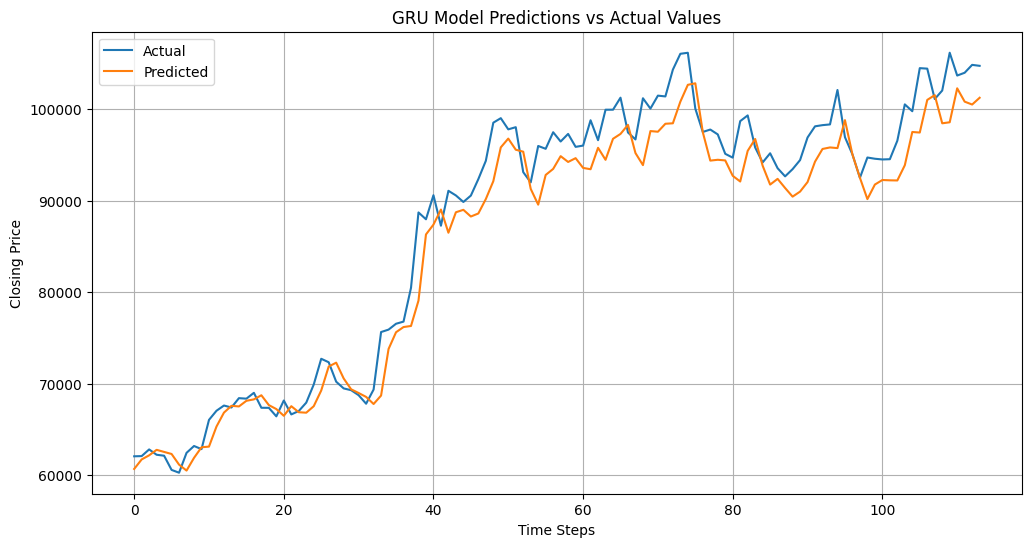

In [ ]:
# prompt: make a plot of the predictions to compare with actual values

# Import necessary library
import matplotlib.pyplot as plt

# ... (Your existing code to load, preprocess data, and train the GRU model)

# Assuming 'scaler' is your MinMaxScaler and 'y_test' is the scaled test data
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))  # Reshape y_test and inverse transform to get actual values


# Plot the predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test_actual, label='Actual')
plt.plot(predicted_price, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Closing Price')
plt.title('GRU Model Predictions vs Actual Values')
plt.legend()
plt.grid(True)
plt.show()

Devo prendere orizzonte temporale per previsione sempre uguale altrimenti come faccio a confrontare previsioni?????????????

## Stesso procedimento per Fear and Greed

In [ ]:
# prompt: now add to the previous gru model fear_greed_index data to see if the performance improve

import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Assuming 'matrix2' DataFrame is already loaded and preprocessed
# ... (Your existing code to load and preprocess data)

# Prepare data for GRU, including 'fear_greed_index'
data = matrix2[['closing_price', 'fear_greed_index']].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Split into train and test
train_size = int(len(data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Create sequences for GRU
def create_sequences(data, seq_length):
  xs = []
  ys = []
  for i in range(len(data)-seq_length-1):
    x = data[i:(i+seq_length)]
    y = data[i+seq_length, 0] # Predict only closing price
    xs.append(x)
    ys.append(y)
  return np.array(xs), np.array(ys)

seq_length = 20  # Adjust sequence length as needed
x_train, y_train = create_sequences(train_data, seq_length)
x_test, y_test = create_sequences(test_data, seq_length)

# Build the GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])))
model.add(GRU(units=50))
model.add(Dense(units=1)) # Output layer for closing price
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, epochs=50, batch_size=32) # Adjust epochs and batch_size as needed

# Make predictions
predicted_price = model.predict(x_test)
predicted_price = scaler.inverse_transform(np.concatenate((predicted_price, x_test[:,-1,1:]), axis=1))[:,0] # Inverse transform and get only closing price

# Evaluate the model
# Extract the original closing prices from the scaled test data
original_closing_prices = scaler.inverse_transform(x_test.reshape(-1, x_test.shape[-1]))[:, 0].reshape(-1, seq_length)[:, -1]  # Reshape and select closing prices

rmse = np.sqrt(mean_squared_error(original_closing_prices, predicted_price))  # Calculate RMSE using original and predicted closing prices
print(f'RMSE: {rmse}')

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0442
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0041
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0014
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 6.8556e-04
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.4566e-04
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 5.0006e-04
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.6854e-04
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.3660e-04
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 5.0626e-04
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 4.8090e-04
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 4.8188e-04
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 5.1235e-04
Epoch 13/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 4.1685e-04
Epoch 14/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9884e-04
Epoch 15/50
17/17 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
# prompt: original_closing_prices count

print(len(original_closing_prices))


114


Così l'errore è molto più piccolo... forse anche troppo...

In [ ]:
# prompt: count predicted_price

# Count the number of elements in the predicted_price array
count_predicted_price = len(predicted_price)
print(f"Number of predicted prices: {count_predicted_price}")


Number of predicted prices: 114


Perchè 114 e quelli del bench 135?

In [ ]:
mape = mean_absolute_percentage_error(original_closing_prices, predicted_price)
print(f"MAPE: {mape}")

MAPE: 0.010472991195346228


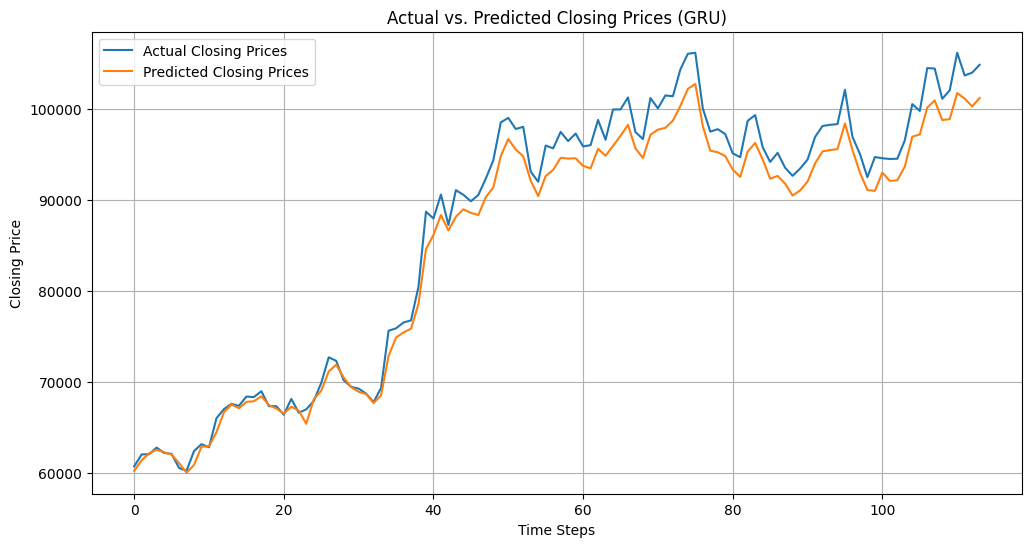

In [ ]:
# prompt: plot original_closing_prices and predicted_price together to compare

# Assuming original_closing_prices and predicted_price are already defined

plt.figure(figsize=(12, 6))
plt.plot(original_closing_prices, label='Actual Closing Prices')
plt.plot(predicted_price, label='Predicted Closing Prices')
plt.xlabel('Time Steps')
plt.ylabel('Closing Price')
plt.title('Actual vs. Predicted Closing Prices (GRU)')
plt.legend()
plt.grid(True)
plt.show()


### Fear and Greed Index

In [ ]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(matrix2, test_size=0.2, shuffle=False) # Use train_test_split for splitting
print(train_data.shape)
test_data.shape

(538, 8)


(135, 8)

In [ ]:
# prompt:  now lets train a GRU model on train_data to forecast closing_prices using fear_greed_index as exogenous variable

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Assuming train_data is your DataFrame with 'closing_price' and 'fear_greed_index'
# Prepare the data for the GRU model

# 1. Scale the data
scaler = MinMaxScaler()
train_data[['closing_price', 'fear_greed_index']] = scaler.fit_transform(train_data[['closing_price', 'fear_greed_index']])


# 2. Create sequences for the GRU
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length, 0]  # Predict closing price
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 20 # Example sequence length. Adjust as needed
X_train, y_train = create_sequences(train_data[['closing_price', 'fear_greed_index']].values, seq_length)

# 3. Build the GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(GRU(units=50))
model.add(Dense(units=1))  # Output layer for closing price prediction

model.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the GRU model
model.fit(X_train, y_train, epochs=50, batch_size=32) # Adjust epochs and batch size as needed

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - loss: 0.1683
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0106
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0045
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0021
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0015
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0015
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0015
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0013
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0014
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0016
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0013
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0013
Epoch 13/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0012
Epoch 14/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0012
Epoch 15/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0012
Epoch 16/50
17/

In [ ]:
# prompt: now lets do the predictions with the gru on test_data and evaluate the results with rmse

# Assuming test_data is your DataFrame and the GRU model is already trained.
# Also, assuming 'scaler' is the MinMaxScaler used for training data.

# 1. Prepare the test data
test_data[['closing_price', 'fear_greed_index']] = scaler.transform(test_data[['closing_price', 'fear_greed_index']])

# 2. Create sequences for the test data
X_test, y_test = create_sequences(test_data[['closing_price', 'fear_greed_index']].values, seq_length)

# 3. Make predictions
gru_predictions = model.predict(X_test)

# 4. Inverse transform the predictions to the original scale
# Fix: Adjust the slicing of test_data[['fear_greed_index']] to match gru_predictions shape
gru_predictions = scaler.inverse_transform(np.concatenate((gru_predictions, test_data[['fear_greed_index']].iloc[seq_length:seq_length + len(gru_predictions)].values), axis=1))[:,0]


# 5. Evaluate the model (RMSE)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test,gru_predictions))

print(f"GRU RMSE: {rmse}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
GRU RMSE: 85557.85657806246


In [ ]:
# prompt: calculate mape

mape = mean_absolute_percentage_error(y_test,gru_predictions)
print(f"MAPE: {mape}")


MAPE: 66662.07321096459


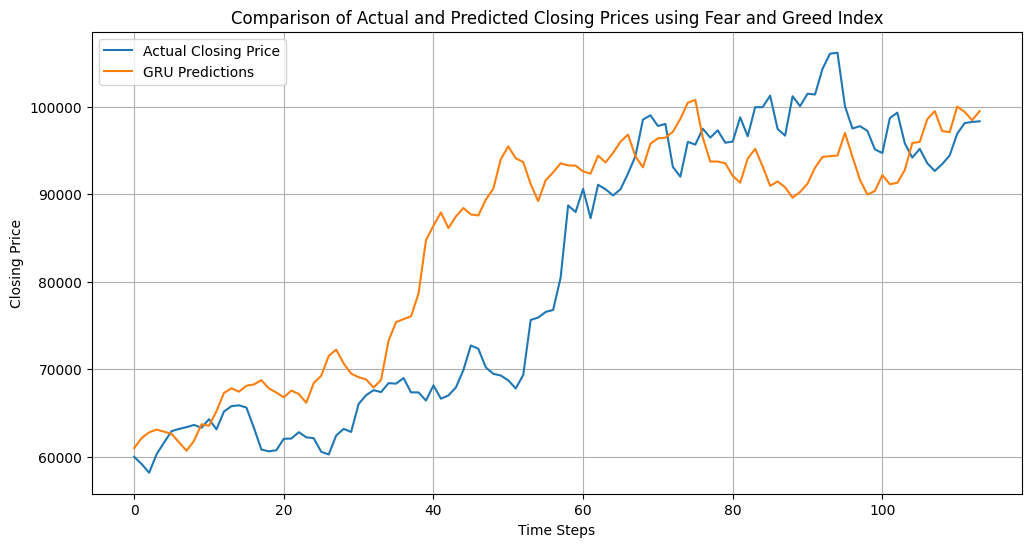

In [ ]:
# prompt: plot gru_predictions test_data closing_price to make a comparison of the two series, both in the same graph after rescaling the closing prices to their original values for the same time interval

# Assuming 'gru_predictions', 'test_data', and 'scaler' are defined as in your provided code.

# Extract the actual closing prices from the test data and inverse transform them
actual_closing_prices = scaler.inverse_transform(test_data[['closing_price', 'fear_greed_index']].values)[:, 0]

# Ensure the lengths of the predictions and actual prices are the same.
#If gru_prediction is longer, slice it:
min_len = min(len(gru_predictions), len(actual_closing_prices))
gru_predictions = gru_predictions[:min_len]
actual_closing_prices = actual_closing_prices[:min_len]

# Plot the predictions and actual prices
plt.figure(figsize=(12, 6))
plt.plot(actual_closing_prices, label='Actual Closing Price')
plt.plot(gru_predictions, label='GRU Predictions')
plt.xlabel('Time Steps')
plt.ylabel('Closing Price')
plt.title('Comparison of Actual and Predicted Closing Prices using Fear and Greed Index')
plt.legend()
plt.grid(True)
plt.show()


Valori mi sembrano altini rispetto al plot

### Lunar *Crush*

In [ ]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(matrix2, test_size=0.2, shuffle=False) # Use train_test_split for splitting
print(train_data.shape)
test_data.shape

(538, 8)


(135, 8)

In [ ]:
# prompt:  now lets train a GRU model on train_data to forecast closing_prices using fear_greed_index as exogenous variable

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Assuming train_data is your DataFrame with 'closing_price' and 'fear_greed_index'
# Prepare the data for the GRU model

# 1. Scale the data
scaler = MinMaxScaler()
train_data[['closing_price', 'galaxy_score']] = scaler.fit_transform(train_data[['closing_price', 'galaxy_score']])


# 2. Create sequences for the GRU
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length, 0]  # Predict closing price
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 10 # Example sequence length. Adjust as needed
X_train, y_train = create_sequences(train_data[['closing_price', 'galaxy_score']].values, seq_length)

# 3. Build the GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(GRU(units=50))
model.add(Dense(units=1))  # Output layer for closing price prediction

model.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the GRU model
model.fit(X_train, y_train, epochs=50, batch_size=32) # Adjust epochs and batch size as needed

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0792
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0088
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0029
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0021
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0014
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0015
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0016
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0012
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0014
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0013
Epoch 13/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0012
Epoch 14/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0011
Epoch 15/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0013
Epoch 16/50
17/

In [ ]:
# prompt: now lets do the predictions with the gru on test_data and evaluate the results with rmse

# Assuming test_data is your DataFrame and the GRU model is already trained.
# Also, assuming 'scaler' is the MinMaxScaler used for training data.

# 1. Prepare the test data
test_data[['closing_price', 'galaxy_score']] = scaler.transform(test_data[['closing_price', 'galaxy_score']])

# 2. Create sequences for the test data
X_test, y_test = create_sequences(test_data[['closing_price', 'galaxy_score']].values, seq_length)

# 3. Make predictions
gru_predictions = model.predict(X_test)

# 4. Inverse transform the predictions to the original scale
# Fix: Adjust the slicing of test_data[['fear_greed_index']] to match gru_predictions shape
gru_predictions = scaler.inverse_transform(np.concatenate((gru_predictions, test_data[['galaxy_score']].iloc[seq_length:seq_length + len(gru_predictions)].values), axis=1))[:,0]


# 5. Evaluate the model (RMSE)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, gru_predictions))

print(f"GRU RMSE: {rmse}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step
GRU RMSE: 83209.52878943535


In [ ]:
# prompt: calculate mape

mape = mean_absolute_percentage_error(y_test,gru_predictions)
print(f"MAPE: {mape}")


MAPE: 67160.6834070668


sono calcolati male i valori sono assurdi

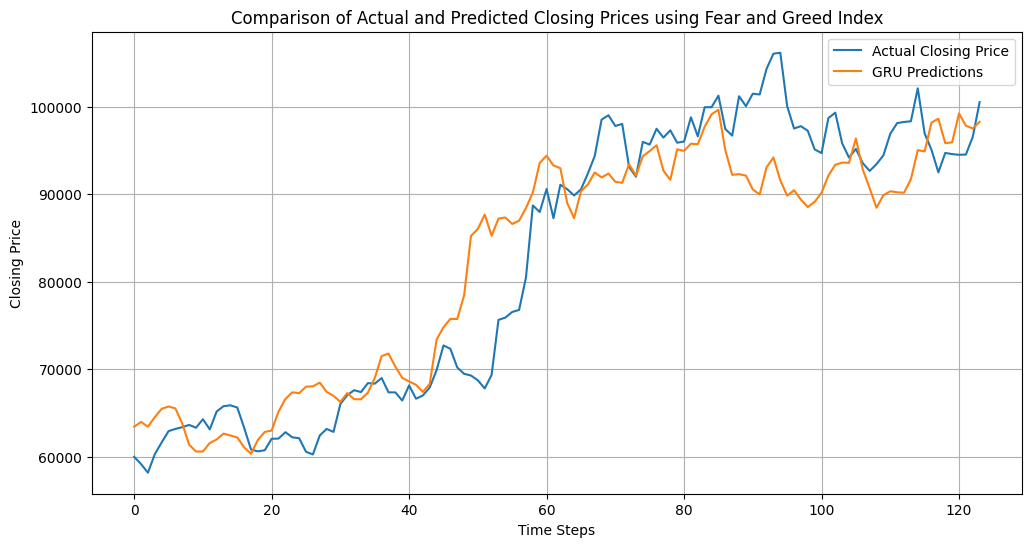

In [ ]:
# prompt: plot gru_predictions test_data closing_price to make a comparison of the two series, both in the same graph after rescaling the closing prices to their original values for the same time interval

# Assuming 'gru_predictions', 'test_data', and 'scaler' are defined as in your provided code.

# Extract the actual closing prices from the test data and inverse transform them
actual_closing_prices = scaler.inverse_transform(test_data[['closing_price', 'galaxy_score']].values)[:, 0]

# Ensure the lengths of the predictions and actual prices are the same.
#If gru_prediction is longer, slice it:
min_len = min(len(gru_predictions), len(actual_closing_prices))
gru_predictions = gru_predictions[:min_len]
actual_closing_prices = actual_closing_prices[:min_len]

# Plot the predictions and actual prices
plt.figure(figsize=(12, 6))
plt.plot(actual_closing_prices, label='Actual Closing Price')
plt.plot(gru_predictions, label='GRU Predictions')
plt.xlabel('Time Steps')
plt.ylabel('Closing Price')
plt.title('Comparison of Actual and Predicted Closing Prices using Fear and Greed Index')
plt.legend()
plt.grid(True)
plt.show()


### Google Trends

In [ ]:
# Split the data into training and testing sets
train_data, test_data = train_test_split(matrix2, test_size=0.2, shuffle=False) # Use train_test_split for splitting
print(train_data.shape)
test_data.shape

(538, 8)


(135, 8)

In [ ]:
# prompt:  now lets train a GRU model on train_data to forecast closing_prices using fear_greed_index as exogenous variable

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Assuming train_data is your DataFrame with 'closing_price' and 'fear_greed_index'
# Prepare the data for the GRU model

# 1. Scale the data
scaler = MinMaxScaler()
train_data[['closing_price', 'Bitcoin_Normalized']] = scaler.fit_transform(train_data[['closing_price', 'Bitcoin_Normalized']])


# 2. Create sequences for the GRU
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length, 0]  # Predict closing price
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_length = 10 # Example sequence length. Adjust as needed
X_train, y_train = create_sequences(train_data[['closing_price', 'Bitcoin_Normalized']].values, seq_length)

# 3. Build the GRU model
model = Sequential()
model.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(GRU(units=50))
model.add(Dense(units=1))  # Output layer for closing price prediction

model.compile(optimizer='adam', loss='mean_squared_error')

# 4. Train the GRU model
model.fit(X_train, y_train, epochs=50, batch_size=32) # Adjust epochs and batch size as needed

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1463
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0093
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0038
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0021
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0016
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0017
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0015
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0015
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0014
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0013
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0014
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0017
Epoch 13/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0013
Epoch 14/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0014
Epoch 15/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0012
Epoc

In [ ]:
# prompt: now lets do the predictions with the gru on test_data and evaluate the results with rmse

# Assuming test_data is your DataFrame and the GRU model is already trained.
# Also, assuming 'scaler' is the MinMaxScaler used for training data.

# 1. Prepare the test data
test_data[['closing_price', 'Bitcoin_Normalized']] = scaler.transform(test_data[['closing_price', 'Bitcoin_Normalized']])

# 2. Create sequences for the test data
X_test, y_test = create_sequences(test_data[['closing_price', 'Bitcoin_Normalized']].values, seq_length)

# 3. Make predictions
gru_predictions = model.predict(X_test)

# 4. Inverse transform the predictions to the original scale
# Fix: Adjust the slicing of test_data[['fear_greed_index']] to match gru_predictions shape
gru_predictions = scaler.inverse_transform(np.concatenate((gru_predictions, test_data[['Bitcoin_Normalized']].iloc[seq_length:seq_length + len(gru_predictions)].values), axis=1))[:,0]


# 5. Evaluate the model (RMSE)
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, gru_predictions))

print(f"GRU RMSE: {rmse}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step
GRU RMSE: 84908.52275390511


# Step 6: Wavelet Analysis

## matrix1 upload

In [ ]:
# prompt: UPLOAD THE csv Bitcoin (BTC) 27mar2023-30gen2025 SANTIMENT from my drive at https://drive.google.com/drive/folders/1lQPvAvh4wthmwDpXeVx0qbF2pqaenjeW

from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving matrix1.csv to matrix1.csv
User uploaded file "matrix1.csv" with length 101301 bytes


In [ ]:
import pandas as pd
from google.colab import files

matrix2 = pd.read_csv('matrix1.csv')
matrix2.head()

,date,closing_price,fear_greed_index,pageviews,ITB Sentiment Score,Bitcoin_Normalized,galaxy_score
0,2021-06-18,35787.246094,25.0,18044,-0.638211,26.707843,61
1,2021-06-19,35615.871094,23.0,15534,-0.592391,24.279857,71
2,2021-06-20,35698.296875,21.0,15696,-0.613527,27.921836,58
3,2021-06-21,31676.693359,23.0,19225,-0.671053,21.566434,67
4,2021-06-22,32505.660156,10.0,21093,-0.738791,29.653846,72


In [ ]:
matrix2.describe()

,closing_price,fear_greed_index,pageviews,ITB Sentiment Score,Bitcoin_Normalized,galaxy_score
count,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000,1314.000000
mean,43148.441105,48.134872,13410.456621,-0.443808,15.598462,57.017504
std,21023.570489,21.251884,7264.047519,0.241174,6.520249,12.966434
min,15787.284180,6.000000,4785.000000,-0.896174,7.018147,40.000000
25%,26678.235840,27.000000,8440.250000,-0.594224,11.011242,44.000000
50%,39453.376953,50.000000,10781.500000,-0.484486,13.713876,58.000000
75%,59117.727539,69.000000,16196.500000,-0.356822,18.623914,70.000000
max,106146.265625,94.000000,83841.000000,0.748627,71.888112,89.000000


In [ ]:
!pip install pyleoclim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.1/656.1 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 81.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.4 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9656 sha256=40f63fc5a4ad81a284db782ff9a2e9c1d5ad44fe766cf9b69586295b50c6c508
  Stored in directory: /r

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import pyleoclim as pyleo
import numpy as np

## BTC closing prices Wavelet

Differenzio i prezzi

NaNs have been detected and dropped.
Time axis values sorted in ascending order


(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': 'Closing Price scalogram (CWT)'}, xlabel='Time [unit]', ylabel='Scale [unit]'>)

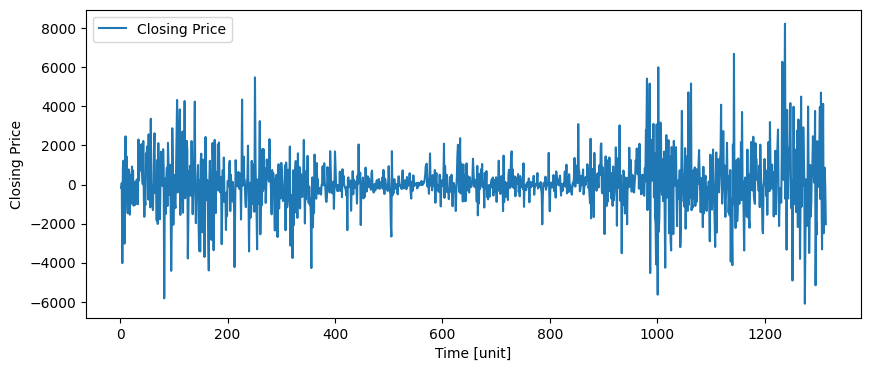

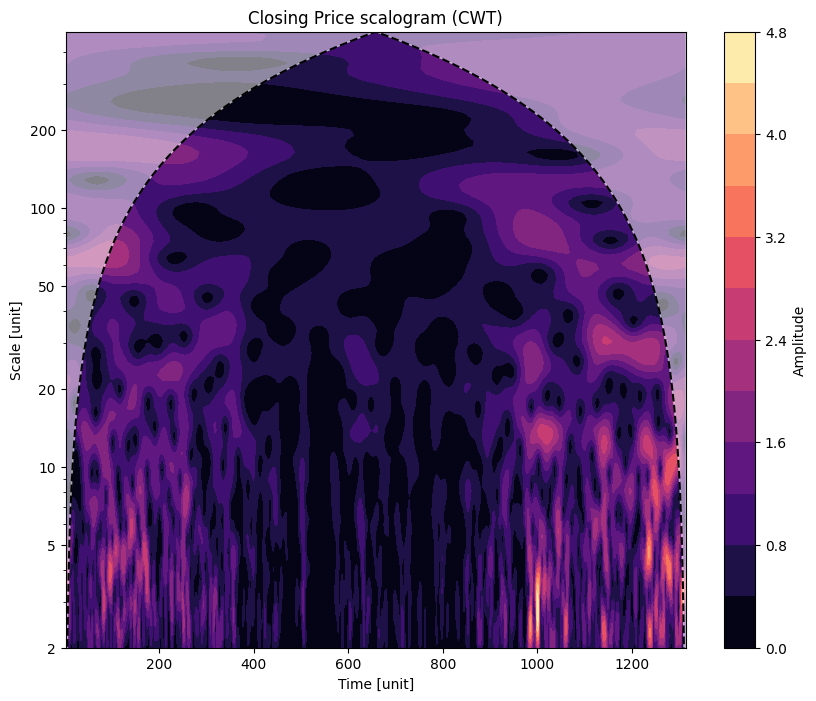

In [ ]:
# prompt: do this for matrix2 cosing_price: # Create a new column 'time' with values from 1 to 2555
# btc_log_return['time'] = range(1, len(btc_log_return) + 1)
# # Now btc_log_return has a 'time' column you can use with pyleoclim
# btc_ts = pyleo.Series(
#     time=btc_log_return['time'],  # Use the new 'time' column
#     value=btc_log_return['log_return'],
#     time_name='Time',  # Changed to 'Time'
#     value_name='Log Return',
#     time_unit='unit', # Changed to a generic unit as 'days' might not apply
#     label='BTC Log Return'
# )
# btc_ts.plot()
# btc_ts

# Assuming 'matrix2' DataFrame is already loaded and 'closing_price' column exists.
# Also assuming 'pyleoclim' is already installed: !pip install pyleoclim

# Create a new column 'time' with values from 1 to the length of the 'closing_price' data.
matrix2['time'] = range(1, len(matrix2) + 1)

# Create a pyleoclim Series object for 'closing_price'
closing_price_ts = pyleo.Series(
    time=matrix2['time'],
    value=matrix2['closing_price'].diff(),
    time_name='Time',
    value_name='Closing Price',
    time_unit='unit',  # Using a generic time unit
    label='Closing Price'
)

# Plot the closing price time series
closing_price_ts.plot()
closing_price_ts

# Analyze time series resolution
#closing_price_ts.resolution().dashboard()

# Perform wavelet analysis
closing_price_scalogram = closing_price_ts.wavelet()
closing_price_scalogram.plot()

## F&G Index

NaNs have been detected and dropped.
Time axis values sorted in ascending order


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Time [unit]', ylabel='...'>)

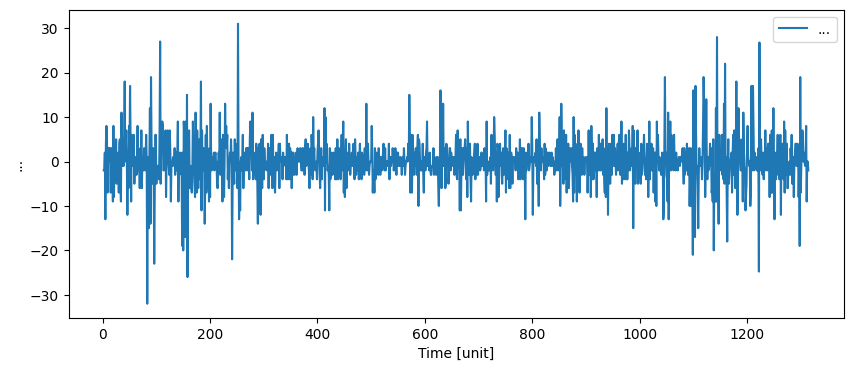

In [ ]:
fng_ts = pyleo.Series(
    time=matrix2['time'],
    value=matrix2['fear_greed_index'].diff(),
    time_name='Time',  # Changed to 'Time'
    value_name='...',
    time_unit='unit', # Changed to a generic unit as 'days' might not apply
    label='...'
)
fng_ts.plot()

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': '... scalogram (CWT)'}, xlabel='Time [unit]', ylabel='Scale [unit]'>)

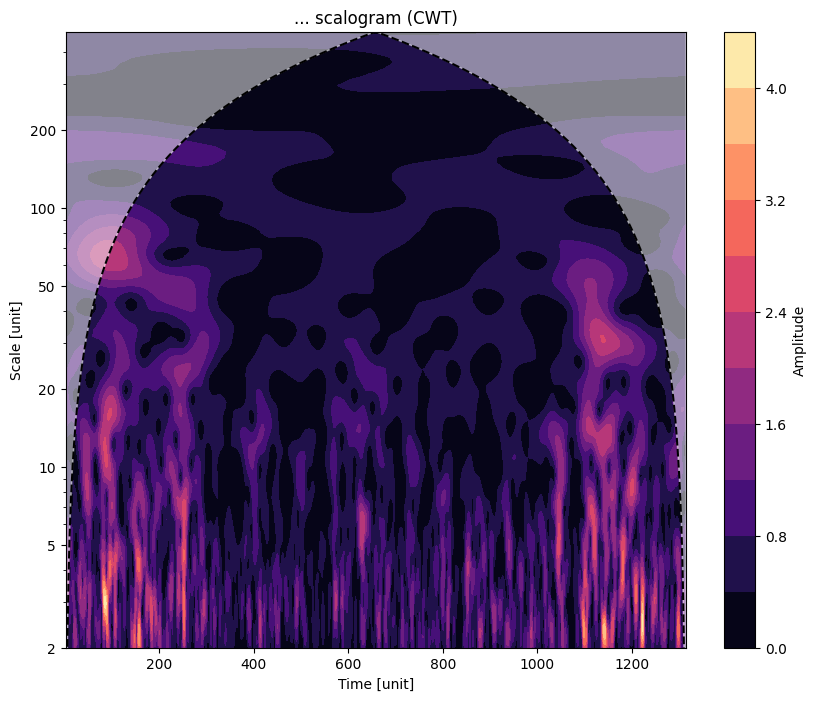

In [ ]:
# Analyze time series resolution
#fng_ts.resolution().dashboard()

# Perform wavelet analysis
fng_scalogram = fng_ts.wavelet()
fng_scalogram.plot()

In [ ]:
btc_ts=closing_price_ts

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='time [unit]', ylabel='value'>)

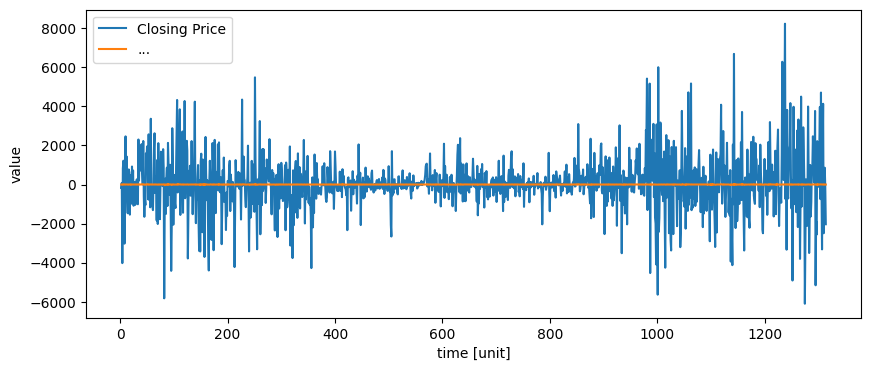

In [ ]:
ms = pyleo.MultipleSeries([btc_ts,fng_ts])
ms.plot()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='time [unit]', ylabel='value'>)

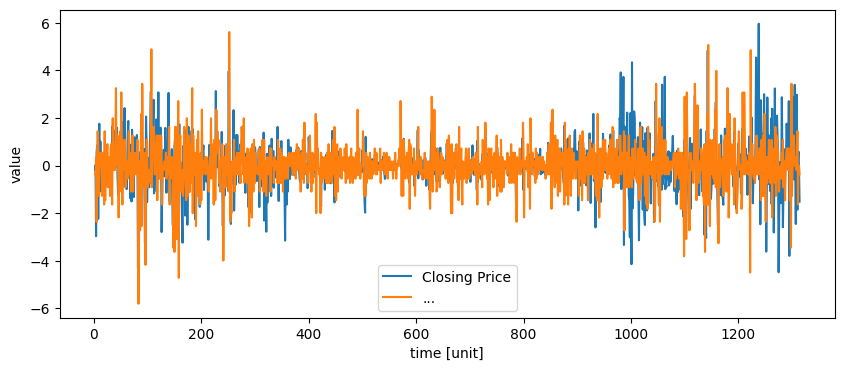

In [ ]:
ms.standardize().plot()

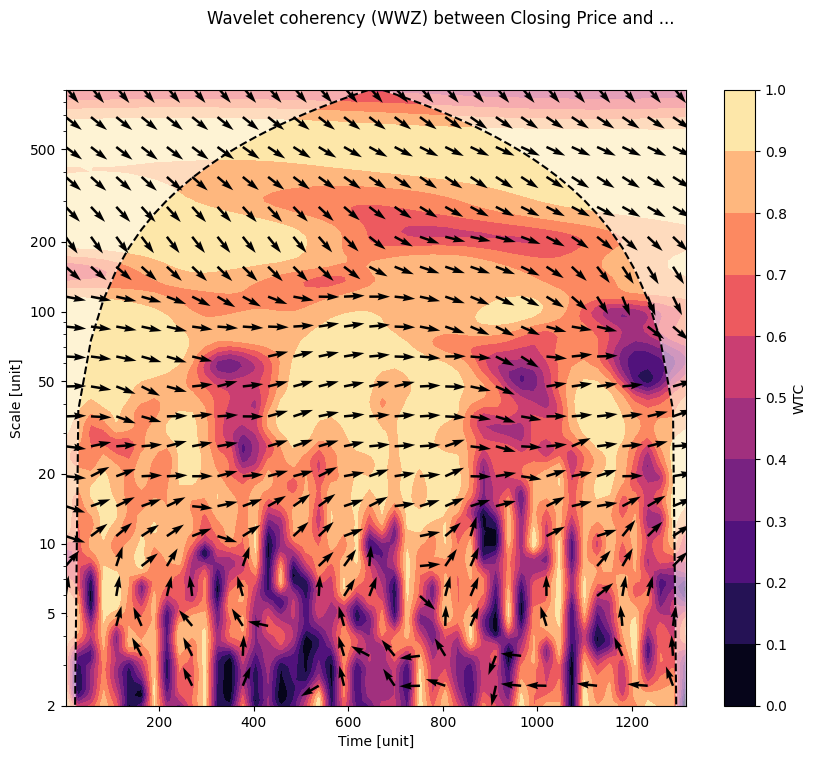

In [ ]:
coh = btc_ts.wavelet_coherence(fng_ts,method='wwz')
fig, ax = coh.plot()

In [ ]:
coh.phase_stats(scales=[80,100])

Results(mean_angle=-0.2378911225841989, kappa=17.46909796942924, sigma=0.24284508743836328, kappa_hi=181.77177964511398, sigma_lo=0.07427393562815733)

In [ ]:
coh_sig = coh.signif_test(method='CN',number=20)

Performing wavelet coherence on surrogate pairs: 100%|██████████| 20/20 [08:43<00:00, 26.15s/it]


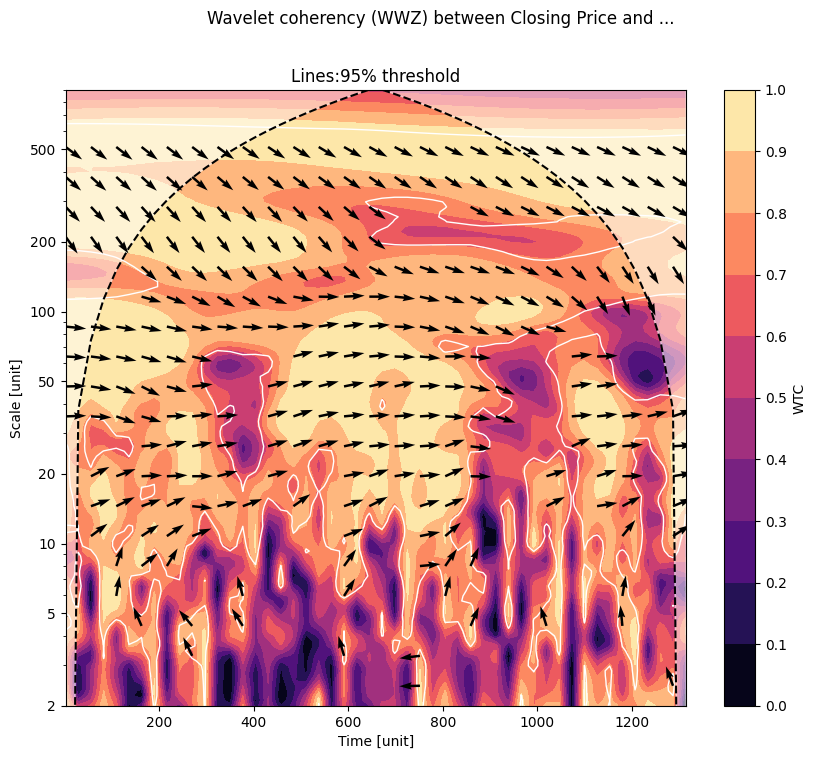

In [ ]:
fig, ax = coh_sig.plot()

## Lunar crush

NaNs have been detected and dropped.
Time axis values sorted in ascending order


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Time [unit]', ylabel='...'>)

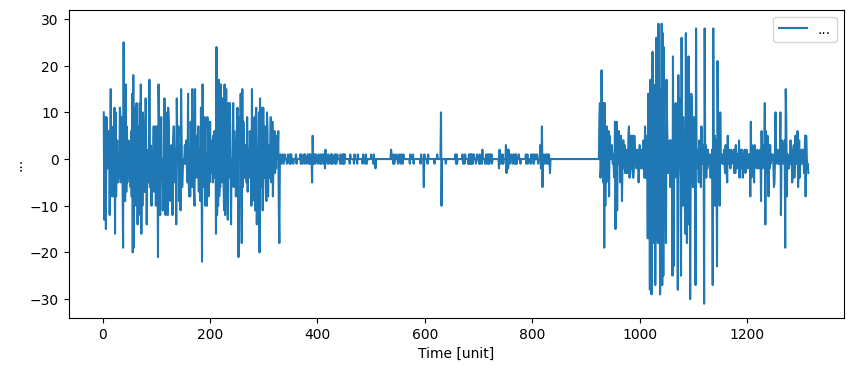

In [ ]:
galaxy_ts = pyleo.Series(
    time=matrix2['time'],
    value=matrix2['galaxy_score'].diff(),
    time_name='Time',  # Changed to 'Time'
    value_name='...',
    time_unit='unit', # Changed to a generic unit as 'days' might not apply
    label='...'
)
galaxy_ts.plot()

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': '... scalogram (CWT)'}, xlabel='Time [unit]', ylabel='Scale [unit]'>)

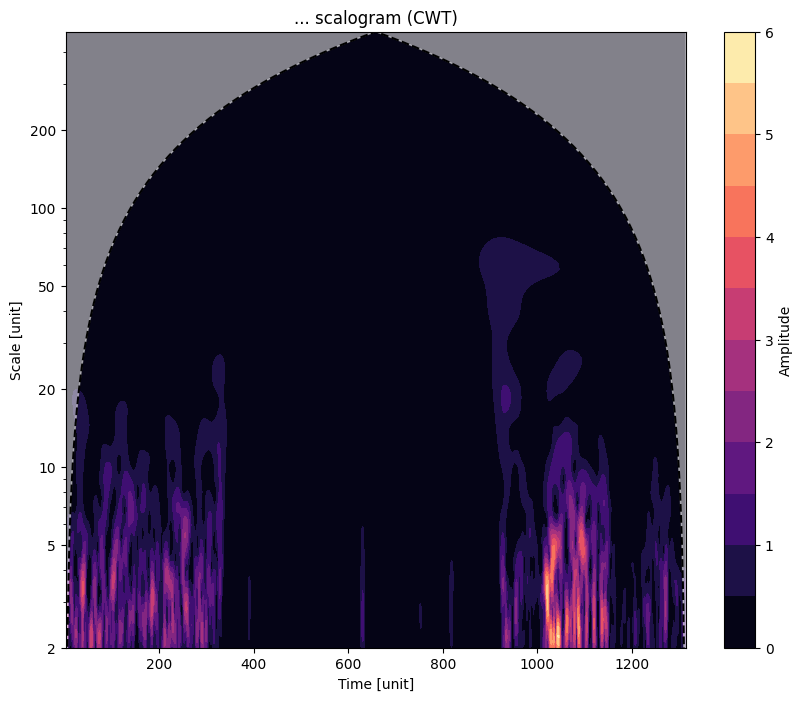

In [ ]:
# Analyze time series resolution
#fng_ts.resolution().dashboard()

# Perform wavelet analysis
galaxy_scalogram = galaxy_ts.wavelet()
galaxy_scalogram.plot()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='time [unit]', ylabel='value'>)

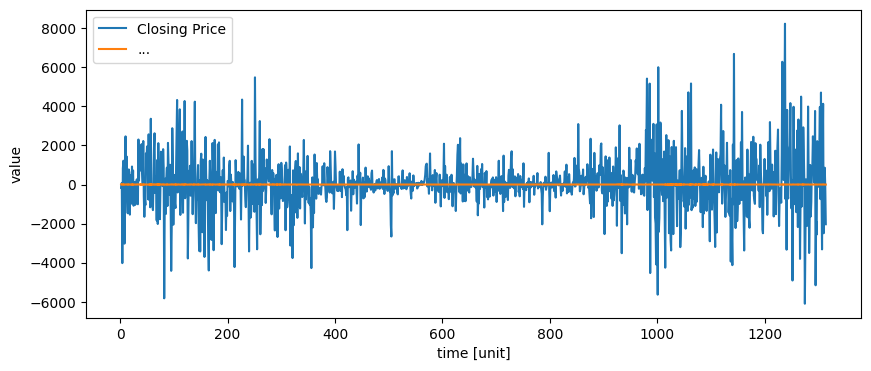

In [ ]:
ms = pyleo.MultipleSeries([btc_ts,galaxy_ts])
ms.plot()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='time [unit]', ylabel='value'>)

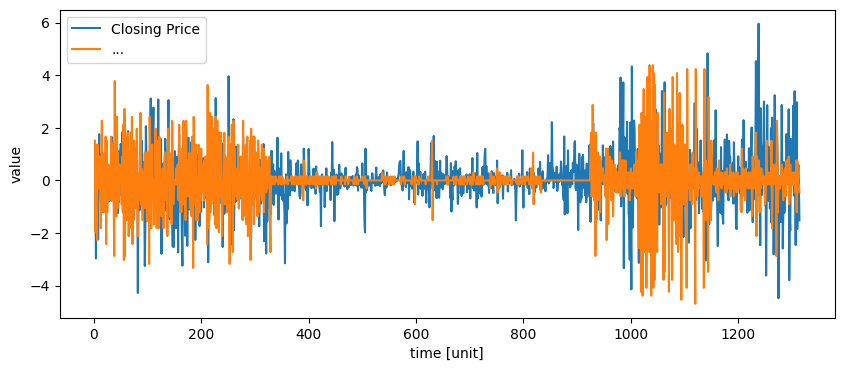

In [ ]:
ms.standardize().plot()

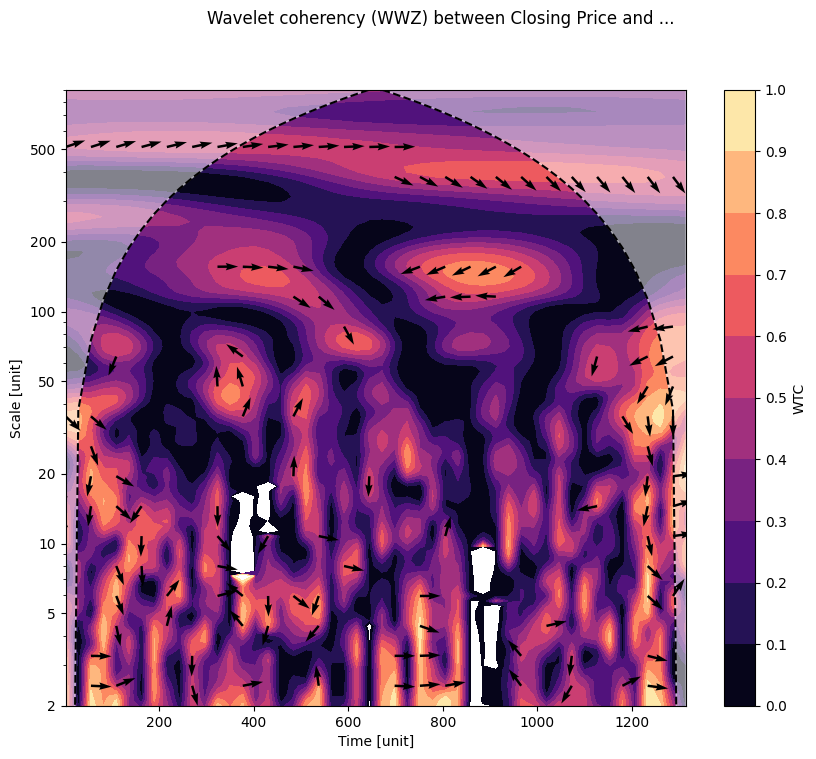

In [ ]:
coh = btc_ts.wavelet_coherence(galaxy_ts,method='wwz')
fig, ax = coh.plot()

Ma che figura è??????????? è come se andasse fuori scala...

In [ ]:
coh.phase_stats(scales=[80,100])

Results(mean_angle=-2.642249081992299, kappa=0.9015308163853444, sigma=1.333308027949621, kappa_hi=0.767299638880129, sigma_lo=1.4329232010548527)

In [ ]:
coh_sig = coh.signif_test(method='CN',number=20)

Performing wavelet coherence on surrogate pairs: 100%|██████████| 20/20 [09:00<00:00, 27.02s/it]


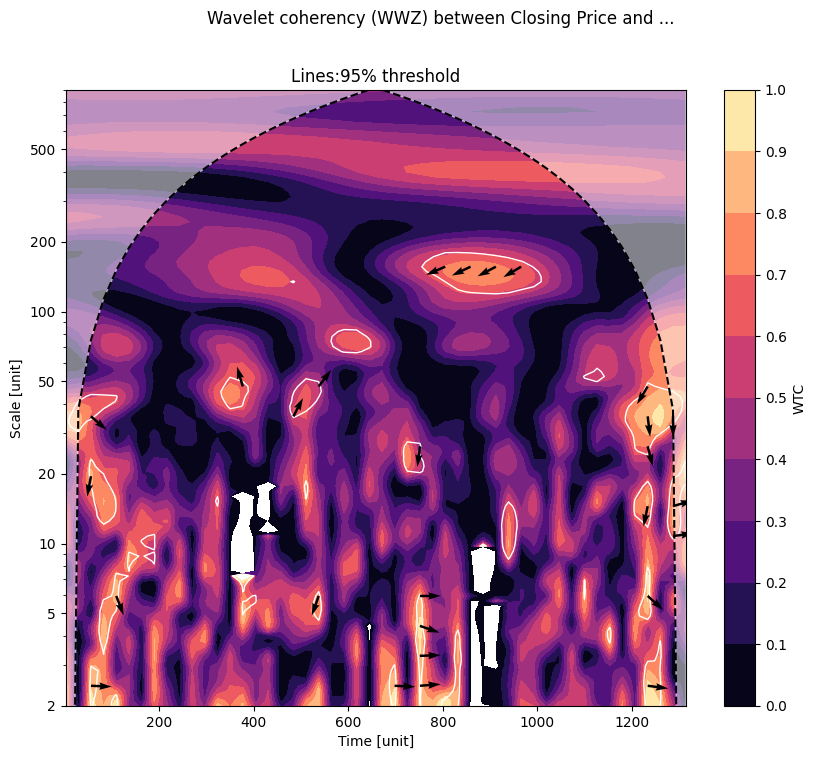

In [ ]:
fig, ax = coh_sig.plot()

## Google Trends Index

NaNs have been detected and dropped.
Time axis values sorted in ascending order


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Time [unit]', ylabel='...'>)

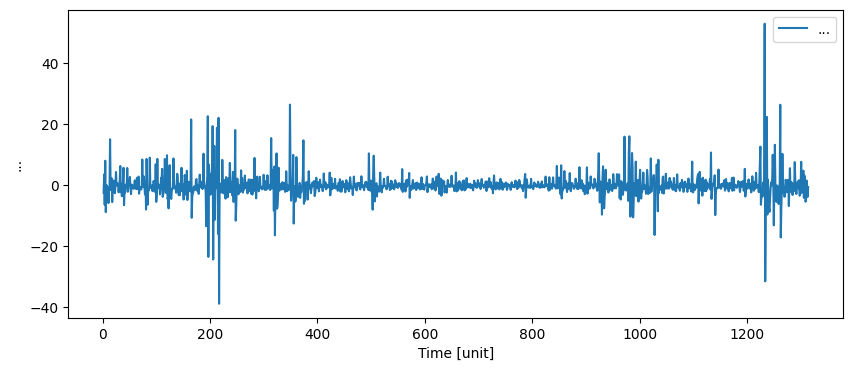

In [ ]:
google_ts = pyleo.Series(
    time=matrix2['time'],
    value=matrix2['Bitcoin_Normalized'].diff(),
    time_name='Time',  # Changed to 'Time'
    value_name='...',
    time_unit='unit', # Changed to a generic unit as 'days' might not apply
    label='...'
)
google_ts.plot()

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': '... scalogram (CWT)'}, xlabel='Time [unit]', ylabel='Scale [unit]'>)

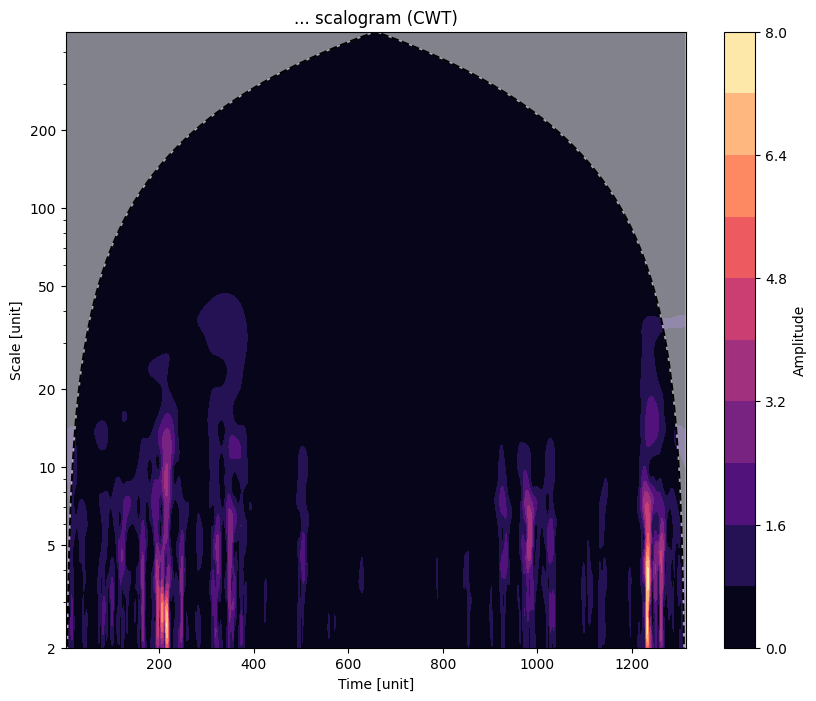

In [ ]:
# Analyze time series resolution
#fng_ts.resolution().dashboard()

# Perform wavelet analysis
google_scalogram = google_ts.wavelet()
google_scalogram.plot()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='time [unit]', ylabel='value'>)

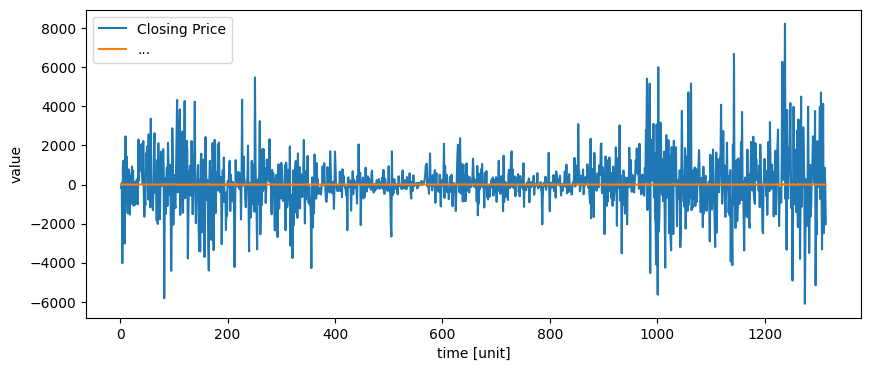

In [ ]:
ms = pyleo.MultipleSeries([btc_ts,google_ts])
ms.plot()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='time [unit]', ylabel='value'>)

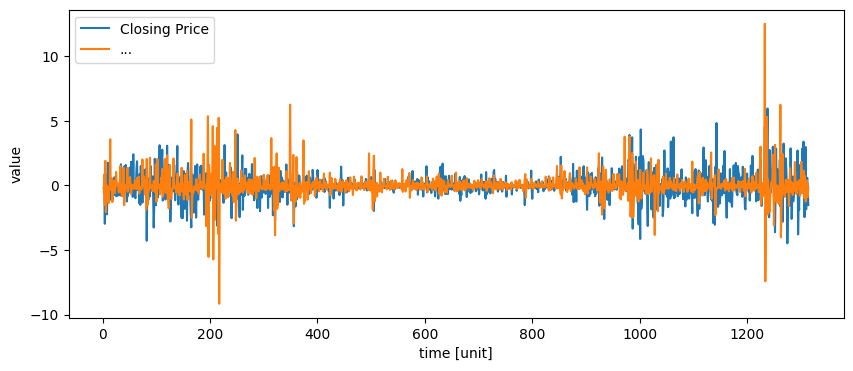

In [ ]:
ms.standardize().plot()

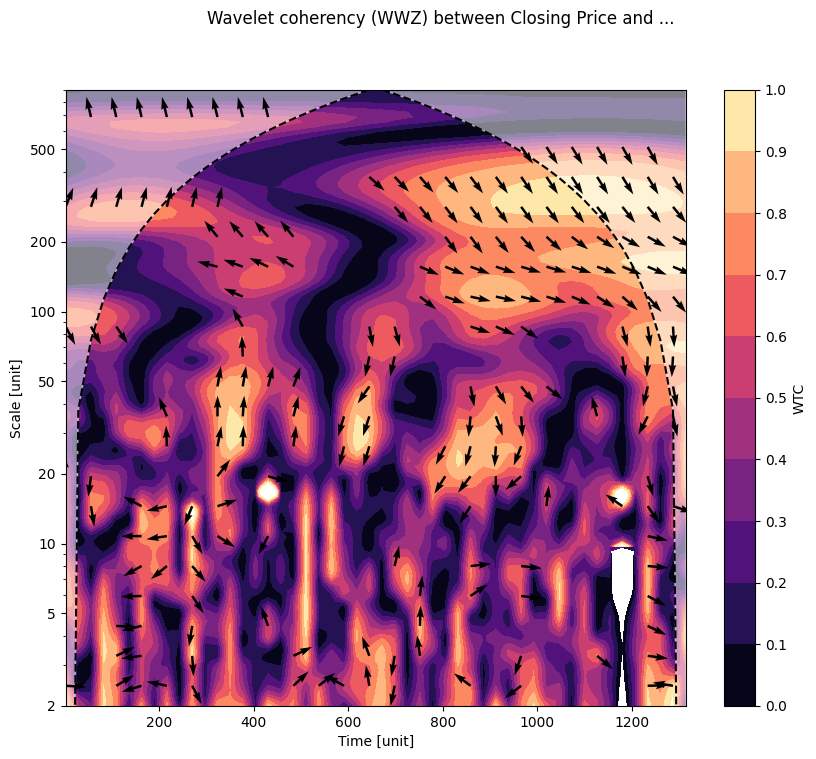

In [ ]:
coh = btc_ts.wavelet_coherence(google_ts,method='wwz')
fig, ax = coh.plot()

Che sono queste zone bianche? stesso problema di Galaxy... out of range???

In [ ]:
coh.phase_stats(scales=[80,100])

Results(mean_angle=-1.0132477172880683, kappa=1.3785638034214758, sigma=1.0664530625717157, kappa_hi=1.8099886509179726, sigma_lo=0.9026368713548291)

In [ ]:
coh_sig = coh.signif_test(method='CN',number=20)

Performing wavelet coherence on surrogate pairs: 100%|██████████| 20/20 [09:44<00:00, 29.21s/it]


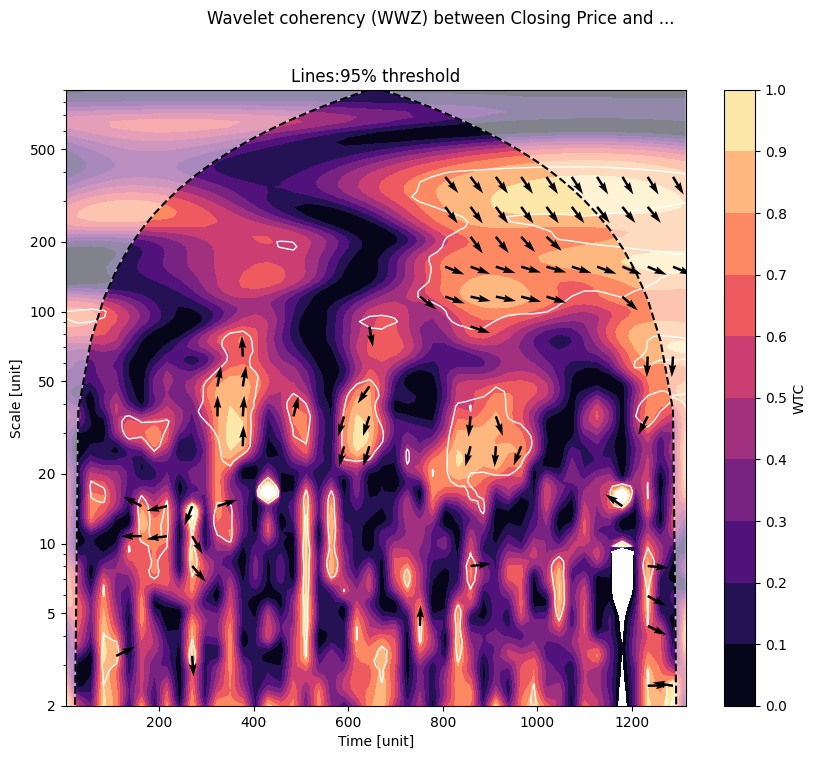

In [ ]:
fig, ax = coh_sig.plot()

## Into the Block

NaNs have been detected and dropped.
Time axis values sorted in ascending order


(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='Time [unit]', ylabel='...'>)

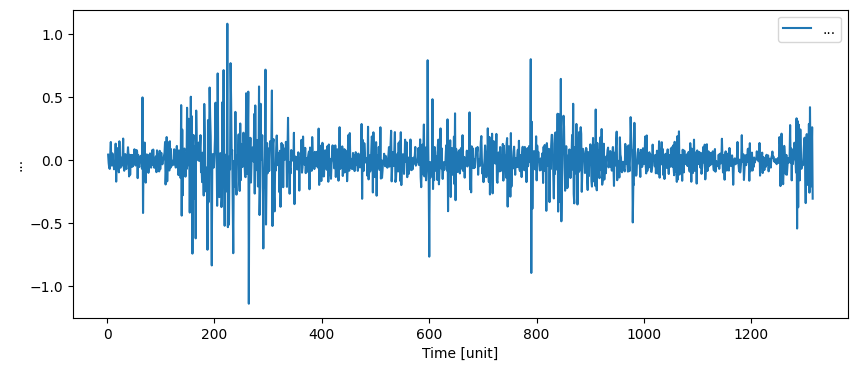

In [ ]:
ITB_ts = pyleo.Series(
    time=matrix2['time'],
    value=matrix2['ITB Sentiment Score'].diff(),
    time_name='Time',  # Changed to 'Time'
    value_name='...',
    time_unit='unit', # Changed to a generic unit as 'days' might not apply
    label='...'
)

ITB_ts.plot()

(<Figure size 1000x800 with 2 Axes>,
 <Axes: title={'center': '... scalogram (CWT)'}, xlabel='Time [unit]', ylabel='Scale [unit]'>)

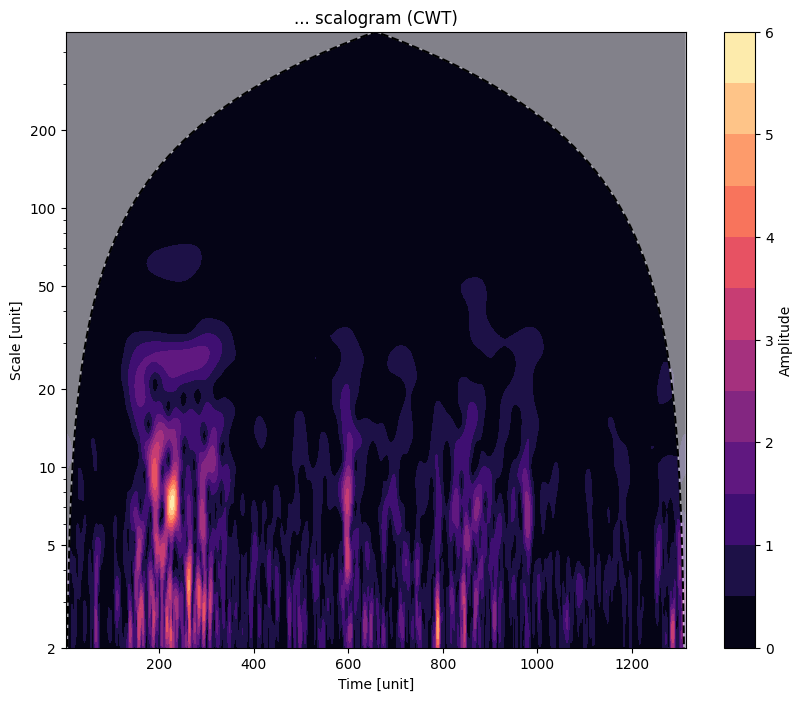

In [ ]:
# Analyze time series resolution
#fng_ts.resolution().dashboard()

# Perform wavelet analysis
ITB_scalogram = ITB_ts.wavelet()
ITB_scalogram.plot()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='time [unit]', ylabel='value'>)

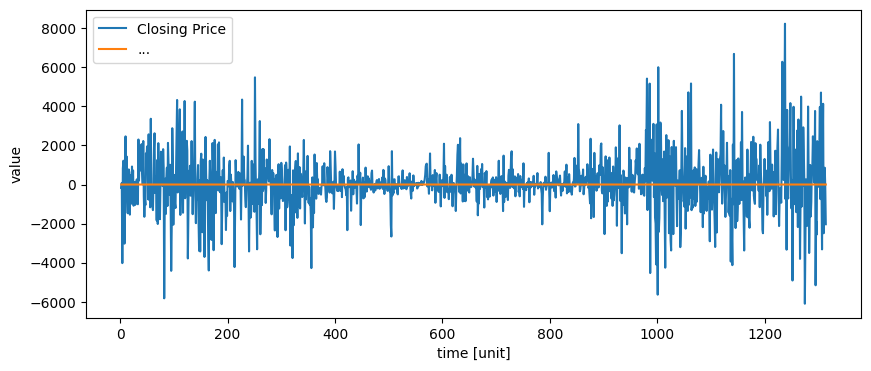

In [ ]:
ms = pyleo.MultipleSeries([btc_ts,ITB_ts])
ms.plot()

(<Figure size 1000x400 with 1 Axes>,
 <Axes: xlabel='time [unit]', ylabel='value'>)

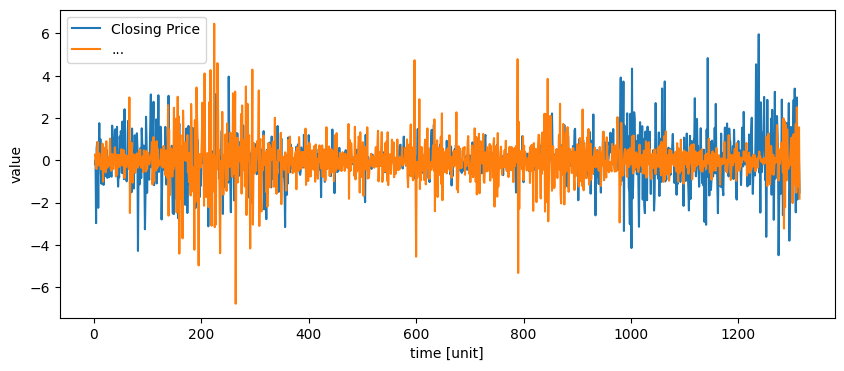

In [ ]:
ms.standardize().plot()

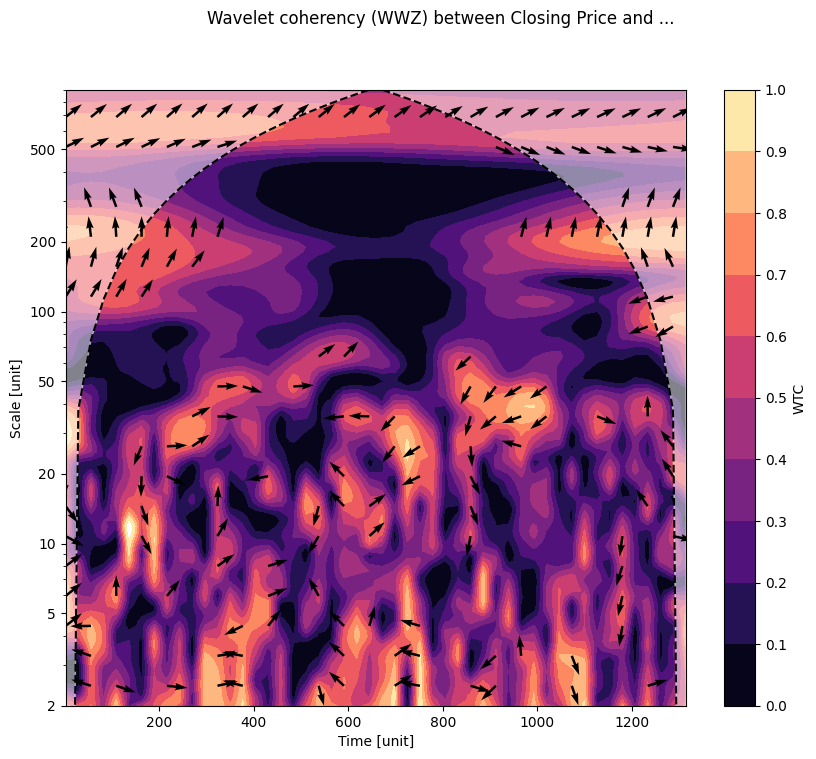

In [ ]:
coh = btc_ts.wavelet_coherence(ITB_ts,method='wwz')
fig, ax = coh.plot()

Questo è ok..

In [ ]:
coh.phase_stats(scales=[80,100])

Results(mean_angle=-0.9385482503257994, kappa=0.024988713033513795, sigma=2.9605932732054554, kappa_hi=1.0553751809547913, sigma_lo=1.2334200492673832)

In [ ]:
coh_sig = coh.signif_test(method='CN',number=20)

Performing wavelet coherence on surrogate pairs: 100%|██████████| 20/20 [08:31<00:00, 25.59s/it]


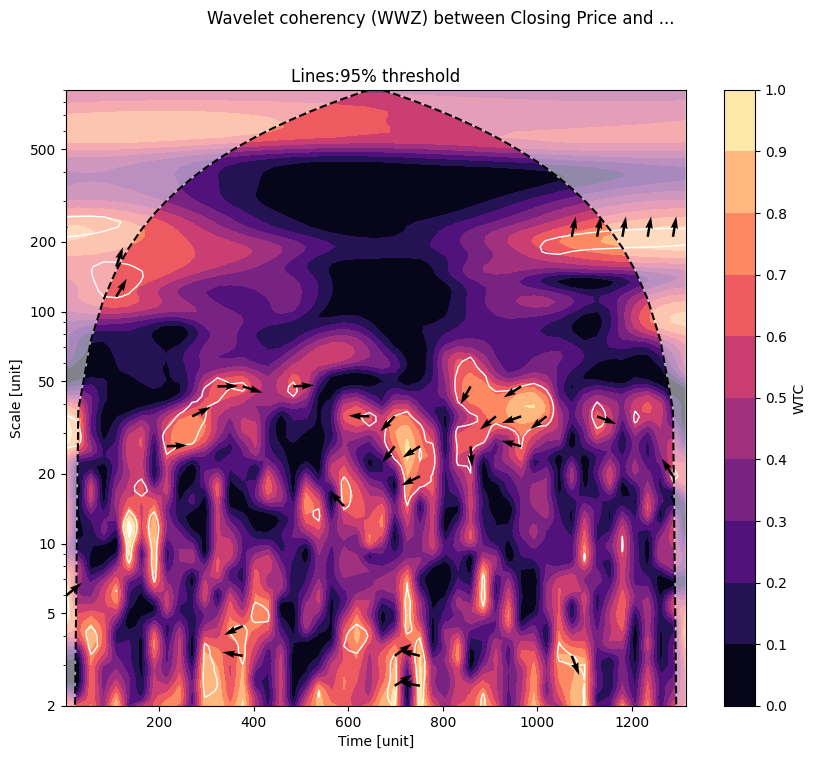

In [ ]:
fig, ax = coh_sig.plot()